# Ice Rheology Part 2: Elasticity and Viscoelasticity — Figures

**Ge 193 — Glacier Dynamics, Spring 2026**

This notebook generates figures for the *Ice Rheology Part 2* lecture on elasticity and viscoelasticity of ice, including Maxwell viscoelastic responses, tidal flexure profiles, and the Deborah number regime diagram.

In [1]:
# ---- Setup: imports and physical constants ----
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

# Elastic moduli of polycrystalline ice (Gammon et al. 1983)
E = 9.33e9       # Pa, Young's modulus
mu = 3.52e9      # Pa, shear modulus
K = 8.90e9       # Pa, bulk modulus
nu = 0.325       # Poisson's ratio
lam = 6.55e9     # Pa, first Lame parameter

# Densities
rho_i = 917.0    # kg m^{-3}, ice
rho_w = 1025.0   # kg m^{-3}, seawater
g = 9.8          # m s^{-2}

# Glen's law parameters
R_gas = 8.314    # J mol^{-1} K^{-1}
n_glen = 3

def A_at_T(T):
    """Rate factor A(T) using Arrhenius relation (Pa^{-3} s^{-1}).

    Reference: Cuffey & Paterson (2010), Table 3.4.
    A_ref = 3.5e-25 at T_ref = 263 K.
    Q = 90 kJ/mol for T < 263 K (fitted to C&P tabulated values);
    Q = 139 kJ/mol for T >= 263 K.
    """
    A_ref = 3.5e-25  # Pa^{-3} s^{-1} at T_ref = 263 K
    T_ref = 263.0
    Q = np.where(np.asarray(T) < 263, 90e3, 139e3)
    return A_ref * np.exp(-Q / R_gas * (1.0 / np.asarray(T) - 1.0 / T_ref))

def maxwell_time(T, tau_e):
    """Maxwell relaxation time (s). T in K, tau_e in Pa."""
    A = A_at_T(T)
    return 1.0 / (2 * mu * A * tau_e**2)

def flexural_wavelength(h):
    """Flexural wavelength (m) for ice shelf of thickness h (m)."""
    D = E * h**3 / (12 * (1 - nu**2))
    return (4 * D / (rho_w * g))**0.25

print('Setup complete.')
print(f'A(270K) = {A_at_T(270):.2e}, A(263K) = {A_at_T(263):.2e}')
print(f'A(243K) = {A_at_T(243):.2e}, A(233K) = {A_at_T(233):.2e}')

Setup complete.
A(270K) = 1.82e-24, A(263K) = 3.50e-25
A(243K) = 1.18e-26, A(233K) = 1.75e-27


---
## Figure 1: Maxwell Viscoelastic Response to Step Loading

Three panels showing the response of a linear Maxwell material to (a) step stress (creep test), (b) step strain (relaxation test), and (c) oscillatory stress (harmonic forcing). These illustrate eqs. (19)–(21) in the lecture notes.

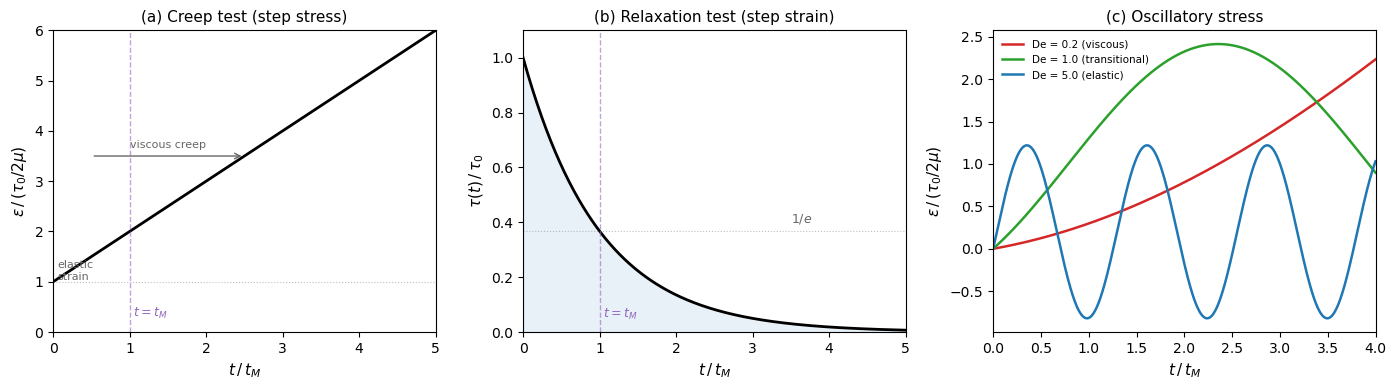

Figure 1 saved.


In [2]:
# ---- Fig 1: Maxwell viscoelastic responses (3 panels) ----
t_M = 1.0  # normalized Maxwell time
tau_0 = 1.0
eps_0 = 1.0
eta = mu * t_M  # effective viscosity (normalized)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- (a) Creep test: step stress ---
ax = axes[0]
t_a = np.linspace(0, 5 * t_M, 500)
eps_creep = tau_0 / (2 * mu) * (1 + t_a / t_M)

# Stress input (top sub-axis via twinx)
ax.plot(t_a / t_M, eps_creep * 2 * mu / tau_0, 'k-', lw=2)
ax.axhline(1.0, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.axvline(1.0, color='#9467bd', ls='--', lw=1, alpha=0.6)
ax.text(1.05, 0.3, '$t = t_M$', fontsize=9, color='#9467bd')

# Annotations
ax.annotate('elastic\nstrain', xy=(0.05, 1.0), fontsize=8, color='0.4',
            ha='left', va='bottom')
ax.annotate('', xy=(2.5, 3.5), xytext=(0.5, 3.5),
            arrowprops=dict(arrowstyle='->', color='0.4', lw=1))
ax.text(1.5, 3.65, 'viscous creep', fontsize=8, color='0.4', ha='center')

ax.set_xlabel('$t \\,/\\, t_M$', fontsize=11)
ax.set_ylabel('$\\varepsilon \\,/\\, (\\tau_0 / 2\\mu)$', fontsize=11)
ax.set_title('(a) Creep test (step stress)', fontsize=11)
ax.set_xlim(0, 5)
ax.set_ylim(0, 6)

# --- (b) Relaxation test: step strain ---
ax = axes[1]
t_b = np.linspace(0, 5 * t_M, 500)
tau_relax = np.exp(-t_b / t_M)

ax.plot(t_b / t_M, tau_relax, 'k-', lw=2)
ax.axhline(1/np.e, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.axvline(1.0, color='#9467bd', ls='--', lw=1, alpha=0.6)
ax.text(1.05, 0.05, '$t = t_M$', fontsize=9, color='#9467bd')
ax.text(3.5, 1/np.e + 0.03, '$1/e$', fontsize=9, color='0.4')

ax.fill_between(t_b / t_M, tau_relax, alpha=0.1, color='#1f77b4')

ax.set_xlabel('$t \\,/\\, t_M$', fontsize=11)
ax.set_ylabel('$\\tau(t) \\,/\\, \\tau_0$', fontsize=11)
ax.set_title('(b) Relaxation test (step strain)', fontsize=11)
ax.set_xlim(0, 5)
ax.set_ylim(0, 1.1)

# --- (c) Harmonic forcing ---
ax = axes[2]
t_c = np.linspace(0, 4, 1000)  # in units of t_M

# Three Deborah numbers
De_vals = [0.2, 1.0, 5.0]
colors_c = ['#d62728', '#2ca02c', '#1f77b4']
labels_c = ['De = 0.2 (viscous)', 'De = 1.0 (transitional)', 'De = 5.0 (elastic)']

for De, col, lab in zip(De_vals, colors_c, labels_c):
    omega_val = De / t_M  # omega = De / t_M
    t_phys = t_c * t_M
    # Strain response: eps = tau_0/(2mu) sin(omega t) + tau_0/(2 eta omega)(1 - cos(omega t))
    eps_harm = (tau_0 / (2 * mu)) * np.sin(omega_val * t_phys) \
             + (tau_0 / (2 * eta * omega_val)) * (1 - np.cos(omega_val * t_phys))
    # Normalize by tau_0/(2mu)
    eps_norm = eps_harm / (tau_0 / (2 * mu))
    ax.plot(t_c, eps_norm, '-', color=col, lw=1.8, label=lab)

ax.set_xlabel('$t \\,/\\, t_M$', fontsize=11)
ax.set_ylabel('$\\varepsilon \\,/\\, (\\tau_0 / 2\\mu)$', fontsize=11)
ax.set_title('(c) Oscillatory stress', fontsize=11)
ax.set_xlim(0, 4)
ax.legend(fontsize=7.5, frameon=False, loc='upper left')

fig.tight_layout()
fig.savefig('figures/fig01_maxwell_responses.pdf', bbox_inches='tight')
fig.savefig('figures/fig01_maxwell_responses.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

---
## Figure 2: Maxwell Time as a Function of Stress and Temperature

Contour plot of $t_M(\tau_e, T)$ showing the enormous range of Maxwell times across glaciological conditions. Overlaid markers show the settings from Table 2 in the lecture notes.

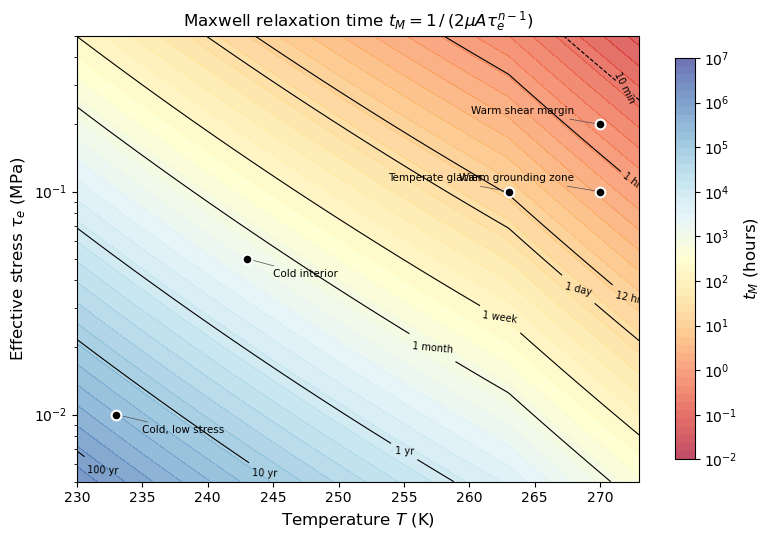

Figure 2 saved.


In [3]:
# ---- Fig 2: Maxwell time contour plot ----

T_arr = np.linspace(230, 273, 300)
tau_arr = np.logspace(np.log10(0.005), np.log10(0.5), 300)  # MPa
T_grid, tau_grid = np.meshgrid(T_arr, tau_arr)

# Compute Maxwell time in hours
t_M_grid = maxwell_time(T_grid, tau_grid * 1e6) / 3600  # hours

fig, ax = plt.subplots(figsize=(8, 5.5))

# Contour levels in hours: 1 min, 10 min, 1 hr, 12 hr, 1 day, 1 week, 1 month, 1 yr, 10 yr, 100 yr
levels_hr = [1/60, 10/60, 1, 12, 24, 24*7, 24*30, 24*365, 24*365*10, 24*365*100, 24*365*1000]
level_labels = ['1 min', '10 min', '1 hr', '12 hr', '1 day', '1 week', '1 month',
                '1 yr', '10 yr', '100 yr', '1000 yr']

cs = ax.contour(T_arr, tau_arr, np.log10(t_M_grid), 
                levels=np.log10(levels_hr), colors='k', linewidths=0.8)

# Manual labels for contours
ax.clabel(cs, cs.levels, inline=True, fontsize=7,
          fmt={lev: lab for lev, lab in zip(np.log10(levels_hr), level_labels)})

# Fill with color
cf = ax.contourf(T_arr, tau_arr, np.log10(t_M_grid),
                 levels=np.linspace(-2, 7, 50), cmap='RdYlBu', alpha=0.7)

# Colorbar with 10^x formatting
cbar = fig.colorbar(cf, ax=ax, shrink=0.9)
cbar.set_label('$t_M$ (hours)', fontsize=12)

# Set colorbar ticks at integer powers and format as 10^x
cbar_ticks = np.arange(-2, 8)  # 10^-2 to 10^7 hours
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels([f'$10^{{{int(t)}}}$' for t in cbar_ticks])

# Mark Table 2 settings
table_settings = [
    (270, 0.2, 'Warm shear margin'),
    (270, 0.1, 'Warm grounding zone'),
    (263, 0.1, 'Temperate glacier'),
    (243, 0.05, 'Cold interior'),
    (233, 0.01, 'Cold, low stress'),
]
for T_val, tau_val, label in table_settings:
    ax.plot(T_val, tau_val, 'ko', ms=7, markeredgecolor='white', markeredgewidth=1.5, zorder=5)
    # Offset labels to avoid overlap
    dx = -2 if T_val > 250 else 2
    dy_factor = 1.15 if tau_val > 0.05 else 0.85
    ax.annotate(label, xy=(T_val, tau_val), xytext=(T_val + dx, tau_val * dy_factor),
                fontsize=7.5, ha='right' if T_val > 250 else 'left', va='center',
                arrowprops=dict(arrowstyle='-', color='0.3', lw=0.5))

ax.set_yscale('log')
ax.set_xlabel('Temperature $T$ (K)', fontsize=12)
ax.set_ylabel('Effective stress $\\tau_e$ (MPa)', fontsize=12)
ax.set_title('Maxwell relaxation time $t_M = 1 \\,/\\, (2\\mu A \\tau_e^{n-1})$', fontsize=12)
ax.set_xlim(230, 273)
ax.set_ylim(0.005, 0.5)

fig.tight_layout()
fig.savefig('figures/fig02_maxwell_time_contours.pdf', bbox_inches='tight')
fig.savefig('figures/fig02_maxwell_time_contours.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

---
## Figure 3: Tidal Flexure Profile at a Grounding Zone

Plot the elastic tidal flexure solution $w(x) = w_0[1 - e^{-x/\ell_f}(\cos(x/\ell_f) + \sin(x/\ell_f))]$ for three ice thicknesses, showing how the flexural wavelength controls the adjustment from grounded to floating ice.

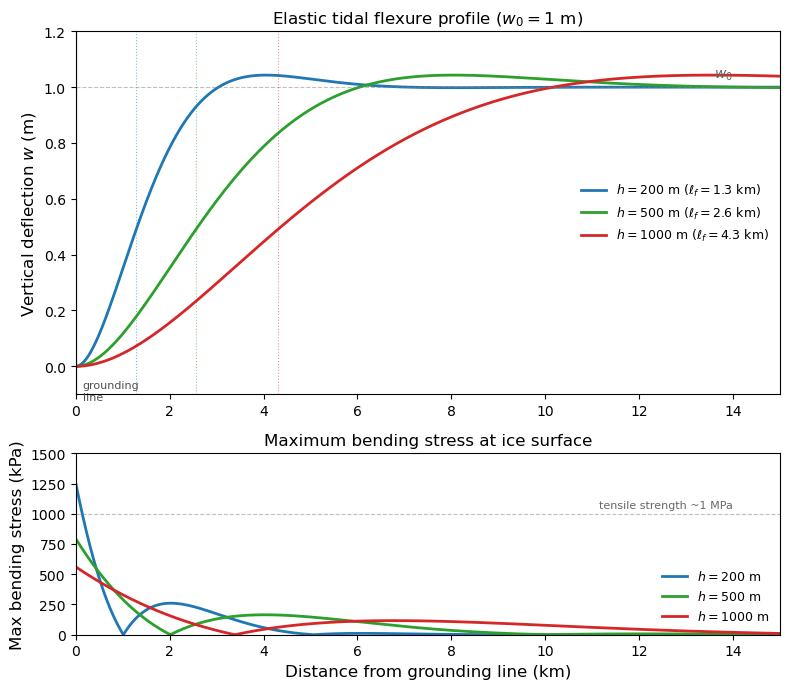

Figure 3 saved.


In [4]:
# ---- Fig 3: Tidal flexure profiles ----
x = np.linspace(0, 15000, 1000)  # m

thicknesses = [200, 500, 1000]  # m
colors_flex = ['#1f77b4', '#2ca02c', '#d62728']

w_0 = 1.0  # m, tidal amplitude

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), gridspec_kw={'height_ratios': [2, 1]})

for h, col in zip(thicknesses, colors_flex):
    lf = flexural_wavelength(h)
    xi = x / lf
    w = w_0 * (1 - np.exp(-xi) * (np.cos(xi) + np.sin(xi)))
    
    ax1.plot(x / 1e3, w, '-', color=col, lw=2,
             label=f'$h = {h}$ m ($\\ell_f = {lf/1e3:.1f}$ km)')
    
    # Mark ell_f on the plot
    ax1.axvline(lf / 1e3, color=col, ls=':', lw=0.8, alpha=0.5)

ax1.axhline(w_0, color='gray', ls='--', lw=0.8, alpha=0.5)
ax1.text(14, w_0 + 0.02, '$w_0$', fontsize=10, color='0.4', va='bottom', ha='right')
ax1.axvline(0, color='k', ls='-', lw=1.5)
ax1.text(0.15, -0.05, 'grounding\nline', fontsize=8, color='0.3', va='top')

ax1.set_ylabel('Vertical deflection $w$ (m)', fontsize=12)
ax1.set_title('Elastic tidal flexure profile ($w_0 = 1$ m)', fontsize=12)
ax1.legend(fontsize=9, frameon=False, loc='center right')
ax1.set_xlim(0, 15)
ax1.set_ylim(-0.1, 1.2)

# Lower panel: bending stress
for h, col in zip(thicknesses, colors_flex):
    lf = flexural_wavelength(h)
    xi = x / lf
    # d2w/dx2 = (2 w_0 / lf^2) * exp(-xi) * sin(xi)
    # Wait, let me derive: w'(xi) = 2 w_0 exp(-xi) sin(xi) (from the notes)
    # w''(xi) = 2 w_0 [exp(-xi)(cos(xi) - sin(xi))]... 
    # Actually d2w/dx2 = (1/lf^2) d2w/dxi2
    # w(xi) = w_0 [1 - exp(-xi)(cos xi + sin xi)]
    # dw/dxi = w_0 * 2 exp(-xi) sin(xi)
    # d2w/dxi2 = w_0 * 2 [exp(-xi)(cos xi - sin xi)]
    d2w_dx2 = w_0 * 2 * np.exp(-xi) * (np.cos(xi) - np.sin(xi)) / lf**2
    sigma_bend = E * h / (2 * (1 - nu**2)) * np.abs(d2w_dx2) / 1e3  # kPa
    
    ax2.plot(x / 1e3, sigma_bend, '-', color=col, lw=2, label=f'$h = {h}$ m')

ax2.axhline(1000, color='gray', ls='--', lw=0.8, alpha=0.5)
ax2.text(14, 1050, 'tensile strength ~1 MPa', fontsize=8, color='0.4', ha='right')

ax2.set_xlabel('Distance from grounding line (km)', fontsize=12)
ax2.set_ylabel('Max bending stress (kPa)', fontsize=12)
ax2.set_title('Maximum bending stress at ice surface', fontsize=12)
ax2.set_xlim(0, 15)
ax2.set_ylim(0, 1500)
ax2.legend(fontsize=9, frameon=False)

fig.tight_layout()
fig.savefig('figures/fig03_tidal_flexure.pdf', bbox_inches='tight')
fig.savefig('figures/fig03_tidal_flexure.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

---
## Figure 4: Deborah Number Regime Diagram

Plot the Deborah number $\text{De} = t_M / t_p$ as a function of process timescale $t_p$ for several glaciological stress/temperature conditions, showing which processes are elastic, viscous, or viscoelastic.

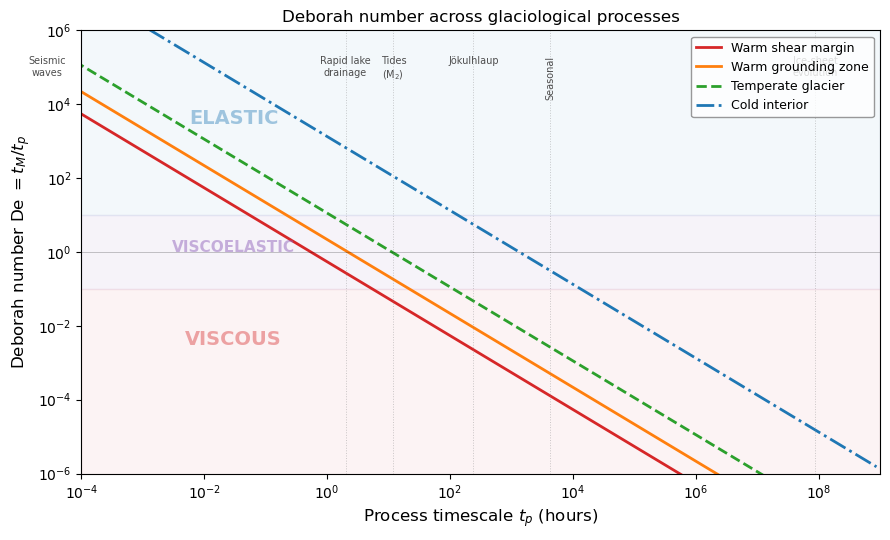

Figure 4 saved.


In [5]:
# ---- Fig 4: Deborah number regime diagram ----
# Process timescales (in seconds)
sec = 1.0
minute = 60
hour = 3600
day = 86400
week = 7 * day
month = 30 * day
year = 365.25 * day

t_p = np.logspace(-2, np.log10(1e5 * year), 500)  # s

# Glaciological settings (T in K, tau_e in Pa)
settings = [
    (270, 0.2e6, 'Warm shear margin', '#d62728', '-'),
    (270, 0.1e6, 'Warm grounding zone', '#ff7f0e', '-'),
    (263, 0.1e6, 'Temperate glacier', '#2ca02c', '--'),
    (243, 0.05e6, 'Cold interior', '#1f77b4', '-.'),
]

fig, ax = plt.subplots(figsize=(9, 5.5))

# Shade regimes
ax.axhspan(0.1, 10, alpha=0.08, color='#9467bd')
ax.axhspan(10, 1e10, alpha=0.05, color='#1f77b4')
ax.axhspan(1e-10, 0.1, alpha=0.05, color='#d62728')

ax.text(3e-2, 3e3, 'ELASTIC', fontsize=14, color='#1f77b4', alpha=0.4,
        ha='center', fontweight='bold')
ax.text(3e-2, 3e-3, 'VISCOUS', fontsize=14, color='#d62728', alpha=0.4,
        ha='center', fontweight='bold')
ax.text(3e-2, 1.0, 'VISCOELASTIC', fontsize=11, color='#9467bd', alpha=0.5,
        ha='center', fontweight='bold')

for T, tau_e, label, col, ls in settings:
    t_M_val = maxwell_time(T, tau_e)
    De = t_M_val / t_p
    ax.loglog(t_p / hour, De, ls, color=col, lw=2, label=label)

# Mark glaciological processes
processes = [
    (0.1 * sec, 'Seismic\nwaves'),
    (12 * hour, 'Tides\n(M$_2$)'),
    (2 * hour, 'Rapid lake\ndrainage'),
    (10 * day, 'Jökulhlaup'),
    (6 * month, 'Seasonal'),
    (1e4 * year, 'Ice-sheet\nevolution'),
]

for t_proc, label in processes:
    ax.axvline(t_proc / hour, color='gray', ls=':', lw=0.7, alpha=0.4)
    ax.text(t_proc / hour, 2e5, label, fontsize=7, ha='center', va='top',
            color='0.3', rotation=90 if len(label) < 10 else 0)

ax.axhline(1.0, color='k', ls='-', lw=0.5, alpha=0.3)

ax.set_xlabel('Process timescale $t_p$ (hours)', fontsize=12)
ax.set_ylabel('Deborah number De $= t_M / t_p$', fontsize=12)
ax.set_title('Deborah number across glaciological processes', fontsize=12)
ax.set_xlim(1e-4, 1e9)
ax.set_ylim(1e-6, 1e6)
ax.legend(fontsize=9, frameon=True, facecolor='white', edgecolor='gray', loc='upper right')

fig.tight_layout()
fig.savefig('figures/fig04_deborah_number.pdf', bbox_inches='tight')
fig.savefig('figures/fig04_deborah_number.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

---
## Figure 5: Supraglacial Lake Flexural Stress

Show how the basal tensile stress beneath a supraglacial lake varies with lake radius and depth, with the tensile strength of ice marked for reference. This complements the worked example in Section 6.3.

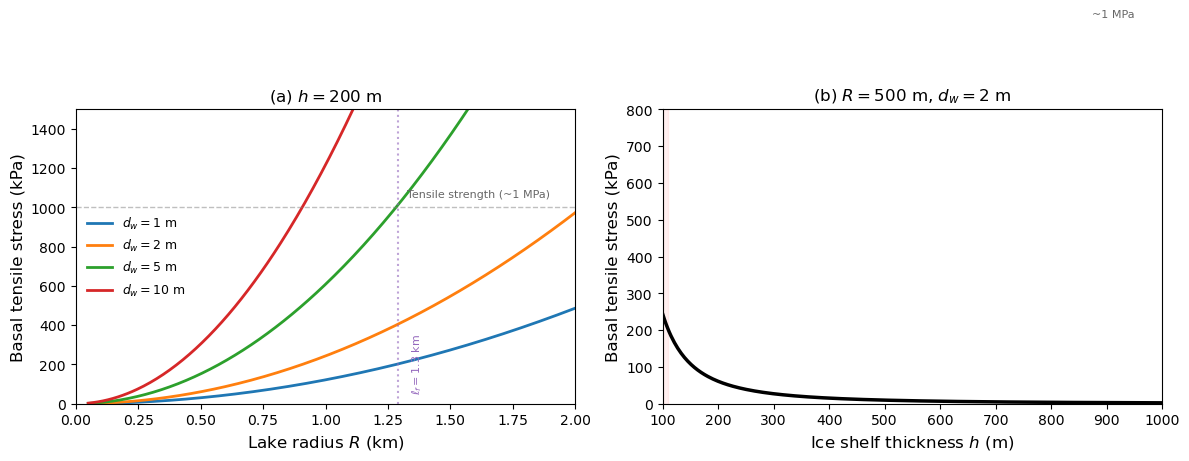

Figure 5 saved.


In [6]:
# ---- Fig 5: Supraglacial lake flexural stress ----
rho_fw = 1000.0  # kg m^{-3}, freshwater

# sigma_tens = 3(1+nu) rho_w g d_w R^2 / (8 h^2)
def lake_stress(d_w, R, h):
    """Basal tensile stress (Pa) beneath circular lake."""
    return 3 * (1 + nu) * rho_fw * g * d_w * R**2 / (8 * h**2)

R_arr = np.linspace(50, 2000, 300)  # m

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Left panel: stress vs lake radius for different depths, h = 200 m ---
h_val = 200  # m
depths = [1, 2, 5, 10]
colors_d = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for d_w, col in zip(depths, colors_d):
    sigma = lake_stress(d_w, R_arr, h_val) / 1e3  # kPa
    ax1.plot(R_arr / 1e3, sigma, '-', color=col, lw=2, label=f'$d_w = {d_w}$ m')

ax1.axhline(1000, color='gray', ls='--', lw=1, alpha=0.5)
ax1.text(1.9, 1050, 'Tensile strength (~1 MPa)', fontsize=8, color='0.4', ha='right')

# Mark the flexural wavelength
lf_200 = flexural_wavelength(h_val)
ax1.axvline(lf_200 / 1e3, color='#9467bd', ls=':', lw=1.5, alpha=0.6)
ax1.text(lf_200 / 1e3 + 0.05, 50, f'$\\ell_f = {lf_200/1e3:.1f}$ km', fontsize=8,
         color='#9467bd', rotation=90, va='bottom')

ax1.set_xlabel('Lake radius $R$ (km)', fontsize=12)
ax1.set_ylabel('Basal tensile stress (kPa)', fontsize=12)
ax1.set_title(f'(a) $h = {h_val}$ m', fontsize=12)
ax1.set_xlim(0, 2)
ax1.set_ylim(0, 1500)
ax1.legend(fontsize=9, frameon=False)

# --- Right panel: stress vs ice thickness for fixed lake, R = 500 m, d_w = 2 m ---
h_arr = np.linspace(100, 1000, 300)
R_fixed = 500  # m
d_fixed = 2    # m

sigma_h = lake_stress(d_fixed, R_fixed, h_arr) / 1e3  # kPa

ax2.plot(h_arr, sigma_h, 'k-', lw=2.5)
ax2.axhline(1000, color='gray', ls='--', lw=1, alpha=0.5)
ax2.text(950, 1050, '~1 MPa', fontsize=8, color='0.4', ha='right')

# Shade the thin-shelf regime where stresses are dangerous
dangerous = sigma_h > 200  # > 200 kPa
if np.any(dangerous):
    h_danger = h_arr[dangerous]
    ax2.axvspan(h_danger[0], h_danger[-1], alpha=0.06, color='red')

ax2.set_xlabel('Ice shelf thickness $h$ (m)', fontsize=12)
ax2.set_ylabel('Basal tensile stress (kPa)', fontsize=12)
ax2.set_title(f'(b) $R = {R_fixed}$ m, $d_w = {d_fixed}$ m', fontsize=12)
ax2.set_xlim(100, 1000)
ax2.set_ylim(0, 800)

fig.tight_layout()
fig.savefig('figures/fig05_lake_stress.pdf', bbox_inches='tight')
fig.savefig('figures/fig05_lake_stress.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

---
## Figure 6: Elastic Moduli Cartoons

Schematic illustrations of the four primary elastic moduli: shear modulus $\mu$, Young's modulus $E$, Poisson's ratio $\nu$, and bulk modulus $K$. Solid rectangles show the undeformed reference state; dashed outlines show the deformed state.

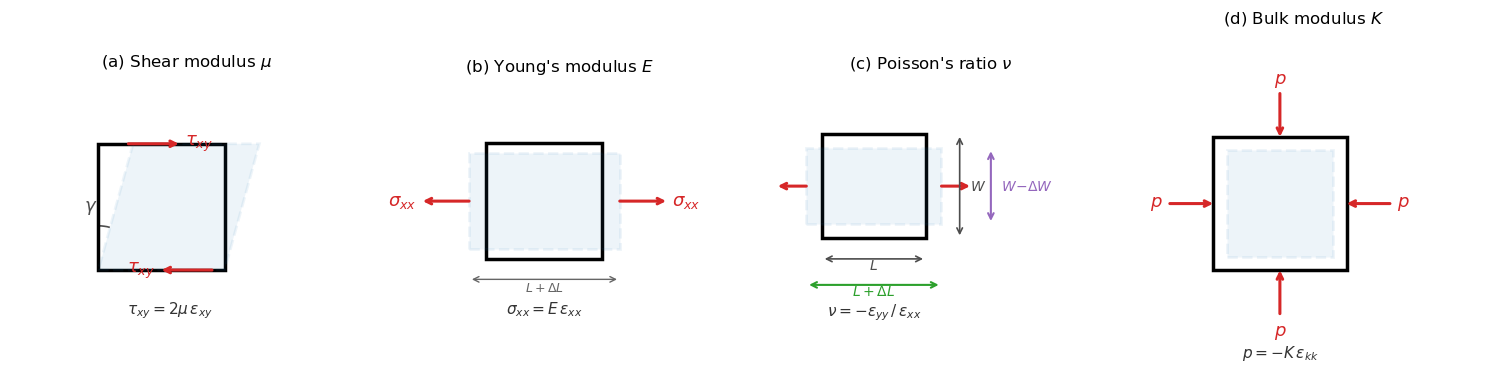

Figure 6 saved.


In [7]:
# ---- Fig 6: Elastic moduli cartoons ----
from matplotlib.patches import Arc

fig, axes = plt.subplots(1, 4, figsize=(15, 5.5))

L = 2.0
lw_ref = 2.5
lw_def = 2.0
col_ref = 'k'
col_def = '#1f77b4'
col_arrow = '#d62728'

def draw_poly(ax, corners, color='k', ls='-', lw=2, fill=False, fc='blue', alpha=0.08):
    poly = plt.Polygon(corners, closed=True, fill=fill,
                        edgecolor=color, ls=ls, lw=lw,
                        facecolor=fc if fill else 'none',
                        alpha=alpha if fill else 1.0, zorder=2)
    ax.add_patch(poly)

def stress_arrow(ax, x, y, dx, dy):
    ax.annotate('', xy=(x+dx, y+dy), xytext=(x, y),
                arrowprops=dict(arrowstyle='->', color=col_arrow, lw=2.2,
                                shrinkA=0, shrinkB=0))

ref = [(0,0), (L,0), (L,L), (0,L)]

# =====================================================================
# (a) Shear modulus — simple shear
# =====================================================================
ax = axes[0]
draw_poly(ax, ref, color=col_ref, lw=lw_ref)

gamma = 0.55
deformed = [(0,0), (L,0), (L+gamma,L), (gamma,L)]
draw_poly(ax, deformed, color=col_def, ls='--', lw=lw_def, fill=True, fc=col_def)

a = 0.8
stress_arrow(ax, gamma/2 + 0.2, L, a, 0)
ax.text(gamma/2 + 0.2 + a + 0.1, L, '$\\tau_{xy}$', fontsize=13, color=col_arrow, va='center')
stress_arrow(ax, L - 0.2, 0, -a, 0)
ax.text(L - 0.2 - a - 0.1, 0, '$\\tau_{xy}$', fontsize=13, color=col_arrow, va='center', ha='right')

arc = Arc((0, 0), 1.4, 1.4, angle=0, theta1=75, theta2=90, color='0.3', lw=1.2)
ax.add_patch(arc)
ax.text(-0.22, 0.95, '$\\gamma$', fontsize=13, color='0.3')

ax.set_title('(a) Shear modulus $\\mu$', fontsize=12, pad=10)
ax.text(L/2 + gamma/4, -0.7, '$\\tau_{xy} = 2\\mu\\,\\varepsilon_{xy}$',
        fontsize=11, ha='center', color='0.2')
ax.set_xlim(-1.4, 4.2); ax.set_ylim(-1.0, 3.0)
ax.set_aspect('equal'); ax.axis('off')

# =====================================================================
# (b) Young's modulus — uniaxial extension
# =====================================================================
ax = axes[1]
draw_poly(ax, ref, color=col_ref, lw=lw_ref)

dx_ext = 0.6
dy_con = 0.35
deformed_E = [(-dx_ext/2, dy_con/2), (L+dx_ext/2, dy_con/2),
              (L+dx_ext/2, L-dy_con/2), (-dx_ext/2, L-dy_con/2)]
draw_poly(ax, deformed_E, color=col_def, ls='--', lw=lw_def, fill=True, fc=col_def)

stress_arrow(ax, L + dx_ext/2, L/2, a, 0)
ax.text(L + dx_ext/2 + a + 0.1, L/2, '$\\sigma_{xx}$', fontsize=13, color=col_arrow, va='center')
stress_arrow(ax, -dx_ext/2, L/2, -a, 0)
ax.text(-dx_ext/2 - a - 0.1, L/2, '$\\sigma_{xx}$', fontsize=13, color=col_arrow, va='center', ha='right')

ax.annotate('', xy=(L+dx_ext/2, -0.35), xytext=(-dx_ext/2, -0.35),
            arrowprops=dict(arrowstyle='<->', color='0.4', lw=1))
ax.text(L/2, -0.55, '$L + \\Delta L$', fontsize=9, ha='center', color='0.4')

ax.set_title("(b) Young's modulus $E$", fontsize=12, pad=10)
ax.text(L/2, -0.95, '$\\sigma_{xx} = E\\,\\varepsilon_{xx}$',
        fontsize=11, ha='center', color='0.2')
ax.set_xlim(-1.8, 4.3); ax.set_ylim(-1.2, 3.0)
ax.set_aspect('equal'); ax.axis('off')

# =====================================================================
# (c) Poisson's ratio — show full deformed vs undeformed dimensions
# =====================================================================
ax = axes[2]
draw_poly(ax, ref, color=col_ref, lw=lw_ref)

dx_c = 0.6
dy_c = 0.55
deformed_C = [(-dx_c/2, dy_c/2), (L+dx_c/2, dy_c/2),
              (L+dx_c/2, L-dy_c/2), (-dx_c/2, L-dy_c/2)]
draw_poly(ax, deformed_C, color=col_def, ls='--', lw=lw_def, fill=True, fc=col_def)

# Light stress arrows
stress_arrow(ax, L + dx_c/2, L/2, 0.55, 0)
stress_arrow(ax, -dx_c/2, L/2, -0.55, 0)

# Full-width dimension lines (easier to read than tiny delta arrows)
# Undeformed width (black) — below the shapes
y_dim = -0.4
ax.annotate('', xy=(L, y_dim), xytext=(0, y_dim),
            arrowprops=dict(arrowstyle='<->', color='0.3', lw=1.2))
ax.text(L/2, y_dim - 0.2, '$L$', fontsize=10, ha='center', color='0.3')

# Deformed width (green) — further below
y_dim2 = -0.9
ax.annotate('', xy=(L+dx_c/2, y_dim2), xytext=(-dx_c/2, y_dim2),
            arrowprops=dict(arrowstyle='<->', color='#2ca02c', lw=1.5))
ax.text(L/2, y_dim2 - 0.2, '$L + \\Delta L$', fontsize=10, ha='center',
        color='#2ca02c', fontweight='bold')

# Undeformed height (black) — to the right
x_dim = L + dx_c/2 + 0.35
ax.annotate('', xy=(x_dim, L), xytext=(x_dim, 0),
            arrowprops=dict(arrowstyle='<->', color='0.3', lw=1.2))
ax.text(x_dim + 0.2, L/2, '$W$', fontsize=10, va='center', color='0.3')

# Deformed height (purple) — further right
x_dim2 = x_dim + 0.6
ax.annotate('', xy=(x_dim2, L-dy_c/2), xytext=(x_dim2, dy_c/2),
            arrowprops=dict(arrowstyle='<->', color='#9467bd', lw=1.5))
ax.text(x_dim2 + 0.2, L/2, '$W\\! -\\! \\Delta W$', fontsize=10, va='center',
        color='#9467bd', fontweight='bold')

ax.set_title("(c) Poisson's ratio $\\nu$", fontsize=12, pad=10)
ax.text(L/2, -1.5, '$\\nu = -\\varepsilon_{yy}\\,/\\,\\varepsilon_{xx}$',
        fontsize=11, ha='center', color='0.2')
ax.set_xlim(-1.3, 5.5); ax.set_ylim(-1.8, 3.0)
ax.set_aspect('equal'); ax.axis('off')

# =====================================================================
# (d) Bulk modulus — uniform compression
# =====================================================================
ax = axes[3]
draw_poly(ax, ref, color=col_ref, lw=lw_ref)

shrink = 0.4
deformed_bulk = [(shrink/2, shrink/2), (L-shrink/2, shrink/2),
                 (L-shrink/2, L-shrink/2), (shrink/2, L-shrink/2)]
draw_poly(ax, deformed_bulk, color=col_def, ls='--', lw=lw_def, fill=True, fc=col_def)

a_p = 0.65
mid = L/2
stress_arrow(ax, L + a_p, mid, -a_p, 0)
ax.text(L + a_p + 0.1, mid, '$p$', fontsize=13, color=col_arrow, va='center')
stress_arrow(ax, -a_p, mid, a_p, 0)
ax.text(-a_p - 0.1, mid, '$p$', fontsize=13, color=col_arrow, va='center', ha='right')
stress_arrow(ax, mid, L + a_p, 0, -a_p)
ax.text(mid, L + a_p + 0.15, '$p$', fontsize=13, color=col_arrow, ha='center')
stress_arrow(ax, mid, -a_p, 0, a_p)
ax.text(mid, -a_p - 0.15, '$p$', fontsize=13, color=col_arrow, ha='center', va='top')

ax.set_title('(d) Bulk modulus $K$', fontsize=12, pad=10)
ax.text(L/2, -1.3, '$p = -K\\,\\varepsilon_{kk}$',
        fontsize=11, ha='center', color='0.2')
ax.set_xlim(-1.3, 4.0); ax.set_ylim(-1.6, 3.5)
ax.set_aspect('equal'); ax.axis('off')

fig.tight_layout()
fig.savefig('figures/fig06_elastic_moduli_cartoons.pdf', bbox_inches='tight')
fig.savefig('figures/fig06_elastic_moduli_cartoons.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

---
## Figure 7: Elastic Beam Bending — Strain and Stress Through the Thickness

Illustrate the Kirchhoff–Love kinematic assumption: strain varies linearly through the thickness, and the resulting elastic bending stress is also linear. Shows a bent beam cross-section alongside the strain and stress profiles (Appendix D).

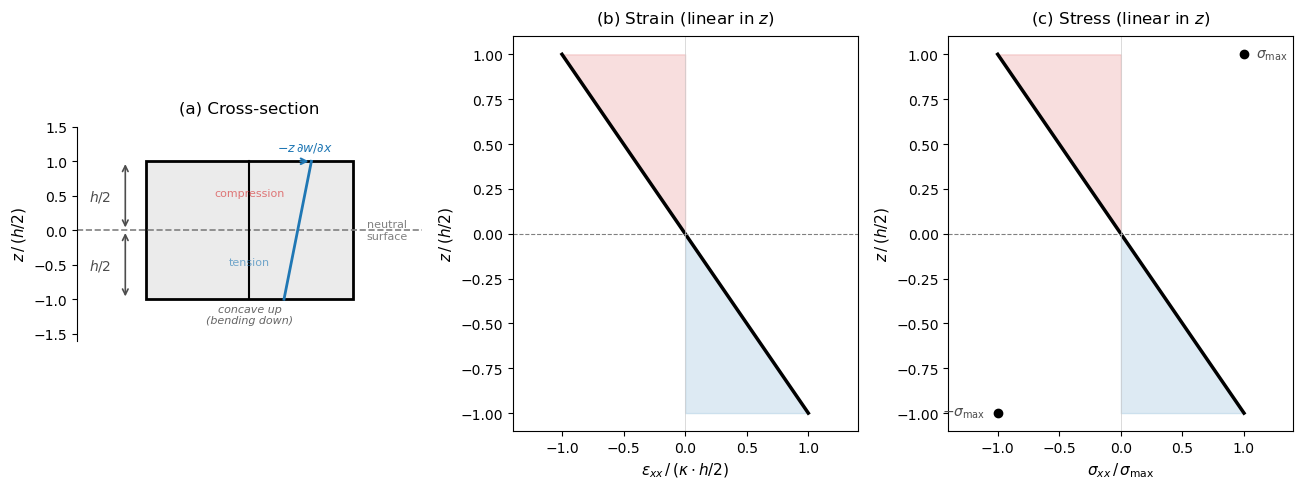

Figure 7 saved.


In [8]:
# ---- Fig 7: Elastic bending — strain and stress through thickness ----
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

h = 1.0  # normalized half-thickness = h/2
z = np.linspace(-h, h, 500)  # z from -h/2 to h/2 (normalized by h/2)

# --- (a) Bent beam cross-section schematic ---
ax = axes[0]

# Undeformed rectangle
rect_x = [-1.5, 1.5, 1.5, -1.5]
rect_z = [-1, -1, 1, 1]
ax.fill(rect_x, rect_z, fc='0.92', ec='k', lw=2, zorder=1)

# Neutral axis
ax.axhline(0, color='0.5', ls='--', lw=1.2, zorder=2)
ax.text(1.7, 0, 'neutral\nsurface', fontsize=8, color='0.5', va='center')

# Show how plane sections rotate under bending
# Left section: vertical (undeformed)
ax.plot([0, 0], [-1, 1], 'k-', lw=1.5, zorder=3)
# Right section: rotated (deformed) — tilted to show bending
theta = 0.2  # rotation angle
x_rot = np.array([0, 0]) + np.array([-1, 1]) * np.sin(theta)
z_rot = np.array([-1, 1])
ax.plot(x_rot + 0.7, z_rot, color=col_def, ls='-', lw=2, zorder=3)
ax.annotate('', xy=(0.7 + np.sin(theta), 1), xytext=(0.7, 1),
            arrowprops=dict(arrowstyle='->', color=col_def, lw=1.5))
ax.text(0.7 + np.sin(theta)/2, 1.15, '$-z\\,\\partial w/\\partial x$',
        fontsize=9, color=col_def, ha='center')

# Curvature indication
ax.annotate('concave up\n(bending down)', xy=(0, -1.35), fontsize=8,
            ha='center', color='0.4', style='italic')

# Thickness labels
ax.annotate('', xy=(-1.8, -1), xytext=(-1.8, 0),
            arrowprops=dict(arrowstyle='<->', color='0.3', lw=1.2))
ax.text(-2.0, -0.5, '$h/2$', fontsize=10, ha='right', va='center', color='0.3')
ax.annotate('', xy=(-1.8, 0), xytext=(-1.8, 1),
            arrowprops=dict(arrowstyle='<->', color='0.3', lw=1.2))
ax.text(-2.0, 0.5, '$h/2$', fontsize=10, ha='right', va='center', color='0.3')

# For concave-up bending (kappa > 0): eps_xx = -z*kappa
# z > 0 (top): eps < 0 => compression; z < 0 (bottom): eps > 0 => tension
ax.text(0, 0.5, 'compression', fontsize=8, ha='center', color='#d62728', alpha=0.6)
ax.text(0, -0.5, 'tension', fontsize=8, ha='center', color='#1f77b4', alpha=0.6)

ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-1.6, 1.5)
ax.set_aspect('equal')
ax.set_ylabel('$z \\,/\\, (h/2)$', fontsize=11)
ax.set_title('(a) Cross-section', fontsize=12, pad=10)
ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# --- (b) Strain profile ---
ax = axes[1]
# epsilon_xx = -z * kappa (linear in z)
strain = -z  # normalized by kappa * h/2
ax.plot(strain, z, 'k-', lw=2.5)
ax.fill_betweenx(z, 0, strain, where=(strain > 0), alpha=0.15, color='#1f77b4')
ax.fill_betweenx(z, 0, strain, where=(strain < 0), alpha=0.15, color='#d62728')
ax.axhline(0, color='0.5', ls='--', lw=0.8)
ax.axvline(0, color='0.8', ls='-', lw=0.5)

ax.set_xlabel('$\\varepsilon_{xx} \\,/\\, (\\kappa \\cdot h/2)$', fontsize=11)
ax.set_title('(b) Strain (linear in $z$)', fontsize=12, pad=10)
ax.set_ylim(-1.1, 1.1)
ax.set_xlim(-1.4, 1.4)
ax.set_ylabel('$z \\,/\\, (h/2)$', fontsize=11)

# --- (c) Stress profile ---
ax = axes[2]
# For elastic: sigma_xx proportional to epsilon_xx, so also linear in z
stress_elastic = -z  # normalized
ax.plot(stress_elastic, z, 'k-', lw=2.5, label='Elastic ($\\sigma \\propto z$)')
ax.fill_betweenx(z, 0, stress_elastic, where=(stress_elastic > 0), alpha=0.15, color='#1f77b4')
ax.fill_betweenx(z, 0, stress_elastic, where=(stress_elastic < 0), alpha=0.15, color='#d62728')
ax.axhline(0, color='0.5', ls='--', lw=0.8)
ax.axvline(0, color='0.8', ls='-', lw=0.5)

# Mark max stress at surfaces
ax.plot([-1, 1], [-1, 1], 'o', color='k', ms=6, zorder=5)
ax.text(1.1, 1.0, '$\\sigma_{\\max}$', fontsize=10, va='center', color='0.3')
ax.text(-1.1, -1.0, '$-\\sigma_{\\max}$', fontsize=10, va='center', ha='right', color='0.3')

ax.set_xlabel('$\\sigma_{xx} \\,/\\, \\sigma_{\\max}$', fontsize=11)
ax.set_title('(c) Stress (linear in $z$)', fontsize=12, pad=10)
ax.set_ylim(-1.1, 1.1)
ax.set_xlim(-1.4, 1.4)
ax.set_ylabel('$z \\,/\\, (h/2)$', fontsize=11)

fig.tight_layout()
fig.savefig('figures/fig07_elastic_bending_profiles.pdf', bbox_inches='tight')
fig.savefig('figures/fig07_elastic_bending_profiles.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

---
## Figure 8: Bending Stress Through the Thickness — Newtonian vs Power-Law

Compare the stress distribution through the beam thickness for Newtonian ($n=1$) and power-law ($n=3$, $n=4$) viscous fluids. The Newtonian stress is linear in $z$; the power-law stress varies as $|z|^{1/n}$, concentrating stress near the surfaces (Appendix E).

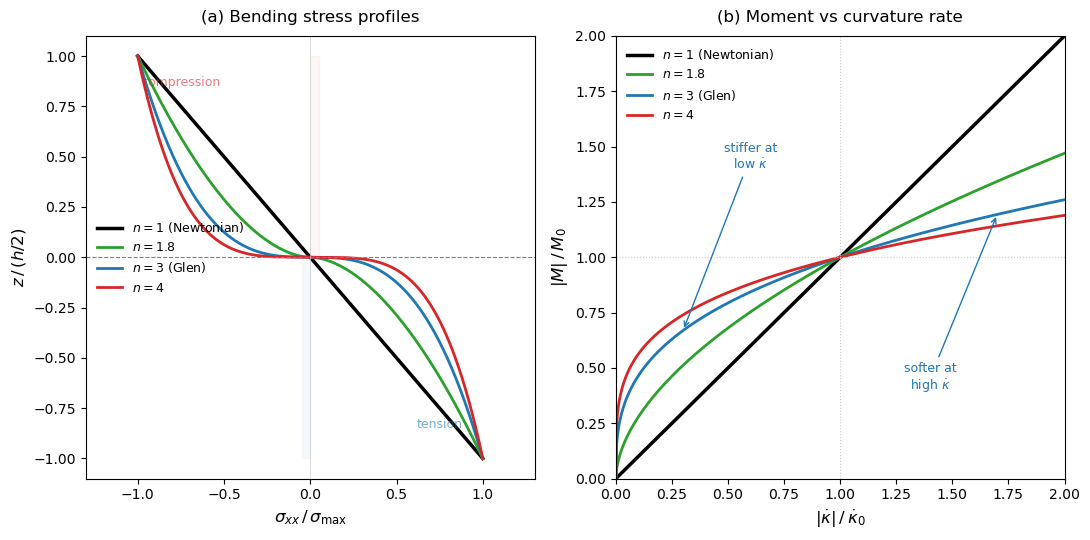

Figure 8 saved.


In [9]:
# ---- Fig 8: Bending stress profiles — Newtonian vs power-law ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5.5))

z = np.linspace(-1, 1, 500)  # z/(h/2)

n_vals = [1, 1.8, 3, 4]
colors_n = ['k', '#2ca02c', '#1f77b4', '#d62728']
labels_n = ['$n = 1$ (Newtonian)', '$n = 1.8$', '$n = 3$ (Glen)', '$n = 4$']

# --- (a) Stress profiles ---
ax = ax1
for n_val, col, lab in zip(n_vals, colors_n, labels_n):
    # sigma_xx(z) = -B |z dot_kappa|^{1/n - 1} (z dot_kappa)
    # Normalized: sigma/sigma_max vs z/(h/2)
    # sigma propto -|z|^{1/n - 1} * z = -|z|^{1/n} * sign(z)
    # At z = 1: sigma = -1 (normalize to surface value)
    stress = -np.sign(z) * np.abs(z)**(1.0/n_val)
    ax.plot(stress, z, '-', color=col, lw=2.5 if n_val == 1 else 2, label=lab)

ax.axhline(0, color='0.5', ls='--', lw=0.8)
ax.axvline(0, color='0.8', ls='-', lw=0.5)

# Shade tension and compression
# For concave-up bending (kappa > 0): eps_xx = -z*kappa
# z > 0 (top): stress < 0 => compression; z < 0 (bottom): stress > 0 => tension
ax.fill_betweenx(z[z >= 0], 0, 0.05, alpha=0.04, color='#d62728')
ax.fill_betweenx(z[z <= 0], -0.05, 0, alpha=0.04, color='#1f77b4')
ax.text(-0.75, 0.85, 'compression', fontsize=9, color='#d62728', alpha=0.6, ha='center')
ax.text(0.75, -0.85, 'tension', fontsize=9, color='#1f77b4', alpha=0.6, ha='center')

ax.set_xlabel('$\\sigma_{xx} \\,/\\, \\sigma_{\\max}$', fontsize=12)
ax.set_ylabel('$z \\,/\\, (h/2)$', fontsize=12)
ax.set_title('(a) Bending stress profiles', fontsize=12, pad=10)
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=9, frameon=False, loc='center left')

# --- (b) Moment vs curvature-rate ---
ax = ax2
kappa_dot = np.linspace(0, 2, 500)  # normalized curvature rate
kappa_dot[0] = 1e-10  # avoid 0^0

for n_val, col, lab in zip(n_vals, colors_n, labels_n):
    # M propto |kappa_dot|^{1/n}
    # Normalize so M = 1 at kappa_dot = 1
    M = kappa_dot**(1.0/n_val)
    ax.plot(kappa_dot, M, '-', color=col, lw=2.5 if n_val == 1 else 2, label=lab)

ax.axhline(1, color='0.8', ls=':', lw=0.8)
ax.axvline(1, color='0.8', ls=':', lw=0.8)

# Annotate the nonlinearity
ax.annotate('stiffer at\nlow $\\dot{\\kappa}$', xy=(0.3, 0.3**(1/3)), xytext=(0.6, 1.4),
            fontsize=9, color='#1f77b4', ha='center',
            arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=1))
ax.annotate('softer at\nhigh $\\dot{\\kappa}$', xy=(1.7, 1.7**(1/3)), xytext=(1.4, 0.4),
            fontsize=9, color='#1f77b4', ha='center',
            arrowprops=dict(arrowstyle='->', color='#1f77b4', lw=1))

ax.set_xlabel('$|\\dot{\\kappa}| \\,/\\, \\dot{\\kappa}_0$', fontsize=12)
ax.set_ylabel('$|M| \\,/\\, M_0$', fontsize=12)
ax.set_title('(b) Moment vs curvature rate', fontsize=12, pad=10)
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.legend(fontsize=9, frameon=False, loc='upper left')

fig.tight_layout()
fig.savefig('figures/fig08_viscous_bending_stress.pdf', bbox_inches='tight')
fig.savefig('figures/fig08_viscous_bending_stress.png', dpi=200, bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

---
## Figure 9: Tidal Flexure — Elastic vs Newtonian vs Power-Law Viscous

Solve the grounding-zone tidal flexure problem for three rheologies and compare deflection and curvature profiles.

**Elastic**: $D\,w'''' + \rho_w g\,w = \rho_w g\,w_{\mathrm{tide}}$ — instantaneous response (analytical).

**Newtonian viscous**: $D_v\,\dot{w}'''' + \rho_w g\,w = \rho_w g\,w_{\mathrm{tide}}$ — parabolic PDE with phase lag (analytical via complex exponentials for steady-state harmonic response).

**Power-law viscous** ($n=3$): $\frac{d^2}{dx^2}[D_n\,|\dot{w}''|^{1/n-1}\dot{w}''] + \rho_w g\,(w - w_{\mathrm{tide}}) = 0$ — nonlinear, solved by explicit time-stepping using the moment–inversion algorithm.

In [10]:
# ---- Fig 9: Tidal flexure — elastic, Newtonian viscous, power-law viscous ----
# Two versions:
#   (a-d) "Physical" A values from Goldsby & Kohlstedt (2001) and Glen's law at 263 K
#   (e-f) All A values matched so D_eff(kappa_bg) = D_v — isolates the effect of n

# =====================================================================
# Parameters
# =====================================================================
h_plate = 500.0
w0 = 1.0
T_ice = 263.0
T_tide = 12 * 3600.0
omega = 2 * np.pi / T_tide
R_gas_local = 8.314

D_el = E * h_plate**3 / (12 * (1 - nu**2))
ell_f = (4 * D_el / (rho_w * g))**0.25
print(f'Elastic: D = {D_el:.2e} N m, ell_f = {ell_f/1e3:.1f} km')

# Background extensional strain rate
eps_bg = 1e-10  # s^{-1}
kappa_bg = eps_bg / (h_plate / 2)  # equivalent background curvature rate [1/(m*s)]

# =====================================================================
# Flow law parameters from Goldsby & Kohlstedt (2001) Table 5, at T = 263 K
# Converted to Glen convention: eps_ij = A_Glen tau_e^{n-1} tau_ij
# A_Glen = 3^{(n+1)/2}/2 * A_GK_Pa, where A_GK_Pa = A_GK_MPa / (1e6)^n * exp(-Q/RT)
# =====================================================================

def A_Glen_from_GK(A0_MPa, n, Q, T, d=None, p=0):
    """Convert GK parameters to Glen-convention A at temperature T.
    A0_MPa: pre-exponential in MPa^{-n} [m^p] s^{-1}
    If grain-size dependent, divide by d^p first.
    """
    A_GK_MPa = A0_MPa * np.exp(-Q / (R_gas_local * T))
    if d is not None and p > 0:
        A_GK_MPa = A_GK_MPa / d**p
    A_GK_Pa = A_GK_MPa / (1e6)**n
    A_Glen = 3**((n+1)/2) / 2 * A_GK_Pa
    return A_Glen

# n=4: dislocation creep (T<258 K parameters, extrapolated to 263 K)
A_4 = A_Glen_from_GK(4.0e5, 4.0, 60e3, T_ice)
# n=3: Glen's law
A_3 = 3.5e-25  # Pa^{-3} s^{-1} at 263 K
# n=1.8: GBS-accommodated basal slip (T<255 K), d = 1 mm
A_18 = A_Glen_from_GK(3.9e-3, 1.8, 49e3, T_ice, d=1e-3, p=1.4)

# Newtonian reference: viscosity at tau_e = 0.1 MPa from Glen n=3
tau_e_ref = 0.1e6
eta_newt = 1 / (2 * A_3 * tau_e_ref**2)
D_v = eta_newt * h_plate**3 / 3
print(f'Newtonian: D_v = {D_v:.2e} N m s (eta = {eta_newt:.2e} Pa s)')

# Flow law cases: {label: (n, A_Glen)}
flow_cases = {
    1.8: {'A': A_18, 'label': '$n=1.8$ (GBS)'},
    3:   {'A': A_3,  'label': '$n=3$ (Glen)'},
    4:   {'A': A_4,  'label': '$n=4$ (disl.)'},
}

for n_val, info in flow_cases.items():
    edot = info['A'] * tau_e_ref**n_val
    eta = 1 / (2 * info['A'] * tau_e_ref**(n_val-1))
    print(f"  {info['label']}: A = {info['A']:.2e}, "
          f"eps_dot(0.1 MPa) = {edot:.2e}, eta = {eta:.2e}")

# =====================================================================
# Spatial grid
# =====================================================================
Lx = 10 * ell_f; Nel = 80; he = Lx / Nel
x_nodes = np.linspace(0, Lx, Nel + 1)

# =====================================================================
# Hermite cubic FEM — semi-implicit time discretization
# =====================================================================
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve

_gp = np.array([0.5 - np.sqrt(3)/6, 0.5 + np.sqrt(3)/6])
_gw = np.array([0.5, 0.5])

_N_gp = np.zeros((2, 4)); _d2N_gp = np.zeros((2, 4))
for q in range(2):
    xi = _gp[q]
    _N_gp[q] = [1-3*xi**2+2*xi**3, xi*(1-xi)**2, 3*xi**2-2*xi**3, xi**2*(xi-1)]
    _d2N_gp[q] = [-6+12*xi, -4+6*xi, 6-12*xi, -2+6*xi]

_scale = np.array([1.0, he, 1.0, he])
N_phys = _N_gp * _scale[None, :]
B_phys = _d2N_gp / he**2 * _scale[None, :]

K_ref = np.array([_gw[q] * he * np.outer(B_phys[q], B_phys[q]) for q in range(2)])
F_ref = np.array([_gw[q] * he * N_phys[q] for q in range(2)])
M_ref = sum(_gw[q] * he * np.outer(N_phys[q], N_phys[q]) for q in range(2))

ndof = 2 * (Nel + 1)
rows = np.zeros((Nel, 4, 4), dtype=int); cols = np.zeros((Nel, 4, 4), dtype=int)
rhs_rows = np.zeros((Nel, 4), dtype=int)
for e in range(Nel):
    d = np.array([2*e, 2*e+1, 2*e+2, 2*e+3])
    rows[e] = d[:, None] * np.ones(4, dtype=int)[None, :]
    cols[e] = np.ones(4, dtype=int)[:, None] * d[None, :]
    rhs_rows[e] = d
rows_flat = rows.ravel(); cols_flat = cols.ravel()

def compute_D_n(A_Glen, n_nl):
    """Plate flexural rigidity parameter from Glen-convention A."""
    return (4*n_nl/(1+2*n_nl)) * (h_plate/2)**((1.0/n_nl)+2) / A_Glen**(1.0/n_nl)

def solve_wdot_fem(w_curr, w_tide_scalar, D_n, n_nl, dt, wdot_prev=None, picard_iters=3):
    wdot_vec = wdot_prev.copy() if wdot_prev is not None else np.zeros(ndof)
    for iteration in range(picard_iters if n_nl > 1 else 1):
        D_eff = np.full((Nel, 2), D_n)
        if n_nl > 1:
            for e in range(Nel):
                dv = wdot_vec[2*e:2*e+4]
                for q in range(2):
                    wpp = B_phys[q] @ dv
                    eps_eff = np.sqrt(wpp**2 + kappa_bg**2)
                    D_eff[e, q] = D_n * eps_eff**((1.0/n_nl) - 1)
        K_elem = (D_eff[:, 0, None, None] * K_ref[0]
                + D_eff[:, 1, None, None] * K_ref[1]
                + dt * rho_w * g * M_ref)
        K_global = csr_matrix((K_elem.ravel(), (rows_flat, cols_flat)), shape=(ndof, ndof)).tolil()
        w_gp = w_curr[:-1, None] * (1 - _gp[None, :]) + w_curr[1:, None] * _gp[None, :]
        load = rho_w * g * (w_tide_scalar - w_gp)
        F_elem = load[:, 0, None] * F_ref[0] + load[:, 1, None] * F_ref[1]
        F_global = np.zeros(ndof)
        np.add.at(F_global, rhs_rows.ravel(), F_elem.ravel())
        for bc in [0, 1]:
            K_global[bc, :] = 0; K_global[:, bc] = 0
            K_global[bc, bc] = 1.0; F_global[bc] = 0.0
        wdot_vec = spsolve(K_global.tocsr(), F_global)
    return wdot_vec

def run_power_law(n_nl, D_n, label='', n_cycles=6):
    """Run the FEM solver for a given n and D_n."""
    D_eff_bg = D_n * kappa_bg**((1.0/n_nl) - 1)
    print(f'  {label}: D_n = {D_n:.2e}, D_eff(kappa_bg) = {D_eff_bg:.2e} '
          f'(ratio to D_v: {D_eff_bg/D_v:.2f})')
    dt = 30.0
    n_steps = int(n_cycles * T_tide / dt)
    steps_per_cycle = int(T_tide / dt)
    save_every = max(1, steps_per_cycle // 200)
    save_start = (n_cycles - 1) * steps_per_cycle
    w = np.zeros(Nel + 1); wdot_prev = None
    w_hist = []; t_hist = []
    for step in range(n_steps):
        t_curr = step * dt; w_tide = w0 * np.sin(omega * t_curr)
        wdot_vec = solve_wdot_fem(w, w_tide, D_n, n_nl, dt,
                                   wdot_prev=wdot_prev, picard_iters=3)
        wdot_prev = wdot_vec; w = w + dt * wdot_vec[0::2]; w[0] = 0
        if step >= save_start and step % save_every == 0:
            w_hist.append(w.copy()); t_hist.append(t_curr)
    t_hist = np.array(t_hist); w_hist = np.array(w_hist)
    phase = omega * t_hist; idx = np.argmax(np.sin(phase)); wp = w_hist[idx]
    print(f'    max|w| = {np.max(np.abs(w_hist)):.3f}, w(L) = {wp[-1]:.4f}, '
          f'dw/dx(L) = {(wp[-1]-wp[-2])/he:.1e}')
    return w_hist, t_hist, w, wdot_prev, D_n

# =====================================================================
# Version 1: Physical A values from GK/Glen
# =====================================================================
print('\n--- Version 1: Physical A values (GK/Glen at 263 K) ---')
nl_phys = {}
for n_val, info in flow_cases.items():
    D_n = compute_D_n(info['A'], n_val)
    w_h, t_h, w_f, wdp, Dn = run_power_law(n_val, D_n, info['label'])
    nl_phys[n_val] = {'hist': w_h, 't': t_h, 'w': w_f, 'wdot_prev': wdp, 'D_n': Dn}

# =====================================================================
# Version 2: Matched D_eff at kappa_bg = D_v for all n
# =====================================================================
print('\n--- Version 2: Matched D_eff(kappa_bg) = D_v ---')
nl_matched = {}
for n_val, info in flow_cases.items():
    # D_n * kappa_bg^{(1/n)-1} = D_v => D_n = D_v * kappa_bg^{1-1/n}
    D_n_matched = D_v * kappa_bg**(1.0 - 1.0/n_val)
    w_h, t_h, w_f, wdp, Dn = run_power_law(n_val, D_n_matched,
                                              info['label'] + ' (matched)')
    nl_matched[n_val] = {'hist': w_h, 't': t_h, 'w': w_f, 'wdot_prev': wdp, 'D_n': Dn}

x = x_nodes

# =====================================================================
# Analytical solutions
# =====================================================================
def elastic_flexure(x, t, w0, ell_f, omega):
    xi = x / ell_f
    return w0 * np.sin(omega * t) * (1 - np.exp(-xi) * (np.cos(xi) + np.sin(xi)))

def elastic_curvature(x, t, w0, ell_f, omega):
    xi = x / ell_f
    return w0 * np.sin(omega * t) * 2 * np.exp(-xi) * (np.cos(xi) - np.sin(xi)) / ell_f**2

def newtonian_viscous_solution(x, t, w0, D_v, omega, rho_w, g):
    beta = (rho_w * g / (omega * D_v))**0.25
    lam1 = beta * np.exp(1j * 5 * np.pi / 8)
    lam2 = beta * np.exp(1j * 9 * np.pi / 8)
    C1 = w0 * lam2 / (lam1 - lam2)
    C2 = -w0 * lam1 / (lam1 - lam2)
    eta_hat = C1 * np.exp(lam1 * x) + C2 * np.exp(lam2 * x)
    return np.imag((w0 + eta_hat) * np.exp(1j * omega * t))

def newtonian_viscous_curvature(x, t, w0, D_v, omega, rho_w, g):
    beta = (rho_w * g / (omega * D_v))**0.25
    lam1 = beta * np.exp(1j * 5 * np.pi / 8)
    lam2 = beta * np.exp(1j * 9 * np.pi / 8)
    C1 = w0 * lam2 / (lam1 - lam2)
    C2 = -w0 * lam1 / (lam1 - lam2)
    d2 = C1 * lam1**2 * np.exp(lam1 * x) + C2 * lam2**2 * np.exp(lam2 * x)
    return np.imag(d2 * np.exp(1j * omega * t))

print('\nDone.')

Elastic: D = 1.09e+17 N m, ell_f = 2.6 km
Newtonian: D_v = 5.95e+21 N m s (eta = 1.43e+14 Pa s)
  $n=1.8$ (GBS): A = 4.22e-19, eps_dot(0.1 MPa) = 4.22e-10, eta = 1.18e+14
  $n=3$ (Glen): A = 3.50e-25, eps_dot(0.1 MPa) = 3.50e-10, eta = 1.43e+14
  $n=4$ (disl.): A = 3.77e-30, eps_dot(0.1 MPa) = 3.77e-10, eta = 1.32e+14



--- Version 1: Physical A values (GK/Glen at 263 K) ---
  $n=1.8$ (GBS): D_n = 3.39e+16, D_eff(kappa_bg) = 1.10e+22 (ratio to D_v: 1.85)


    max|w| = 1.120, w(L) = 1.0101, dw/dx(L) = 9.0e-06
  $n=3$ (Glen): D_n = 9.58e+13, D_eff(kappa_bg) = 1.76e+22 (ratio to D_v: 2.96)


    max|w| = 1.106, w(L) = 0.9943, dw/dx(L) = 4.0e-06
  $n=4$ (disl.): D_n = 1.00e+13, D_eff(kappa_bg) = 1.99e+22 (ratio to D_v: 3.35)


    max|w| = 1.100, w(L) = 0.9942, dw/dx(L) = 3.4e-06

--- Version 2: Matched D_eff(kappa_bg) = D_v ---
  $n=1.8$ (GBS) (matched): D_n = 1.84e+16, D_eff(kappa_bg) = 5.95e+21 (ratio to D_v: 1.00)


    max|w| = 1.124, w(L) = 1.0343, dw/dx(L) = 1.1e-05
  $n=3$ (Glen) (matched): D_n = 3.23e+13, D_eff(kappa_bg) = 5.95e+21 (ratio to D_v: 1.00)


    max|w| = 1.110, w(L) = 1.0134, dw/dx(L) = 2.5e-06
  $n=4$ (disl.) (matched): D_n = 2.99e+12, D_eff(kappa_bg) = 5.95e+21 (ratio to D_v: 1.00)


    max|w| = 1.103, w(L) = 1.0066, dw/dx(L) = 4.3e-07

Done.


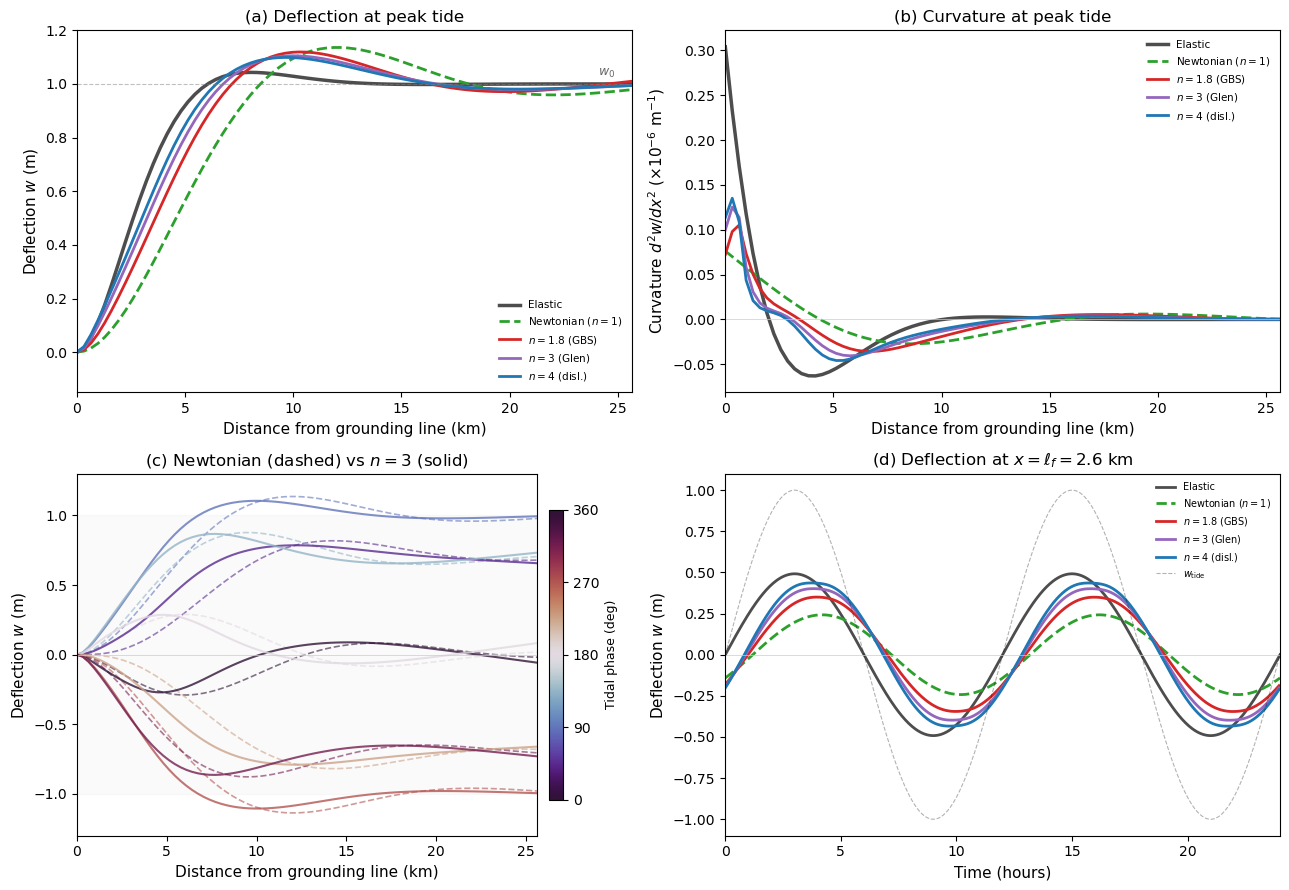

fig09a_tidal_flexure_physical saved.


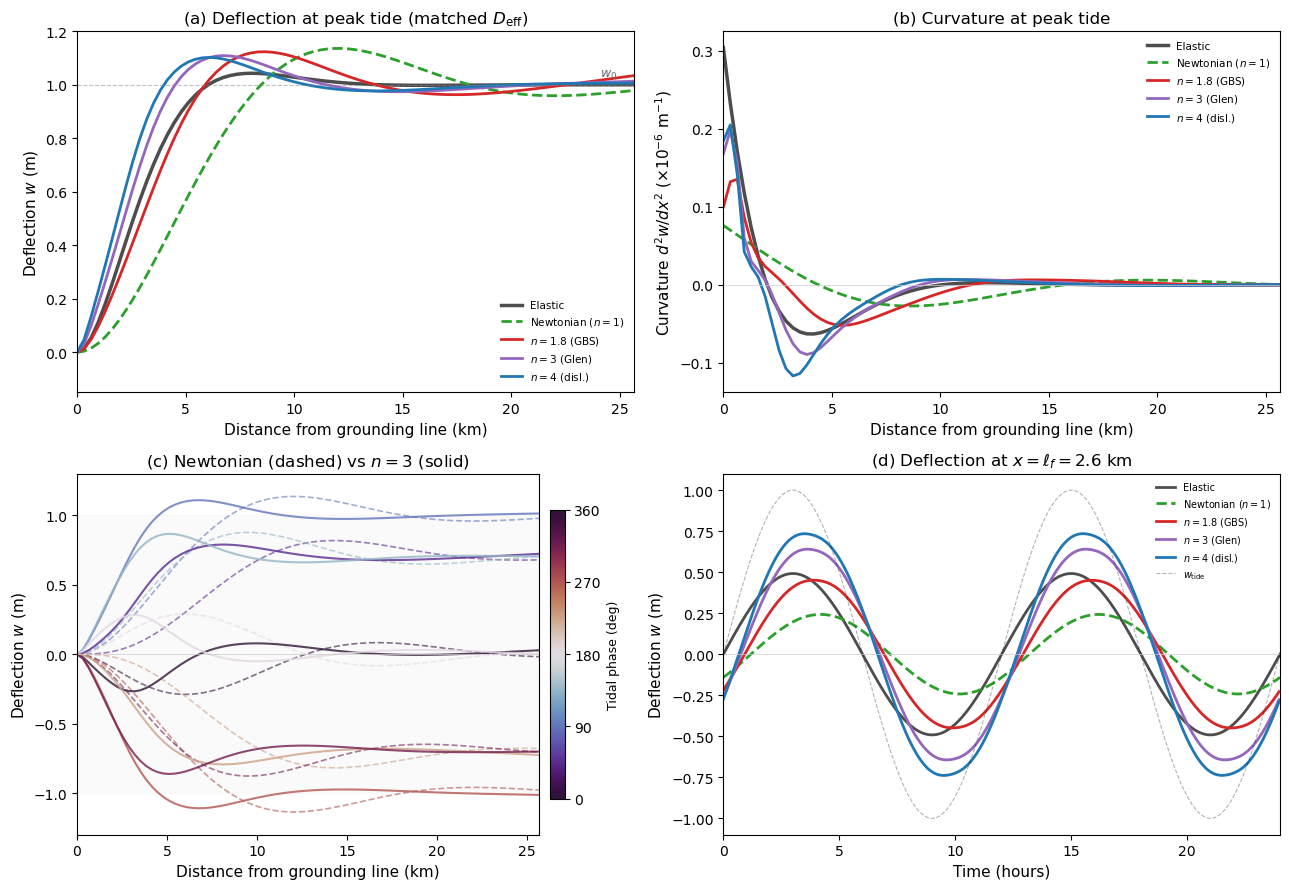

fig09b_tidal_flexure_matched saved.
Figure 9 saved.


In [11]:
# ---- Fig 9a: Tidal flexure with physical A values (GK/Glen at 263 K) ----
col_el = '0.3'; col_newt = '#2ca02c'
col_nl = {1.8: '#d62728', 3: '#9467bd', 4: '#1f77b4'}
dt = 30.0

def plot_flexure_figure(nl_cases, figname, title_suffix=''):
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # (a) Deflection at peak tide
    ax = axes[0, 0]
    ax.plot(x/1e3, elastic_flexure(x, T_tide/4, w0, ell_f, omega),
            '-', color=col_el, lw=2.5, label='Elastic')
    ax.plot(x/1e3, newtonian_viscous_solution(x, T_tide/4, w0, D_v, omega, rho_w, g),
            '--', color=col_newt, lw=2, label='Newtonian ($n=1$)')
    for n_val in [1.8, 3, 4]:
        c = nl_cases[n_val]
        phase = omega * c['t']; idx = np.argmax(np.sin(phase))
        ax.plot(x/1e3, c['hist'][idx], '-', color=col_nl[n_val], lw=2,
                label=flow_cases[n_val]['label'])
    ax.axhline(w0, color='gray', ls='--', lw=0.8, alpha=0.5)
    ax.text(Lx/1e3*0.97, w0+0.03, '$w_0$', fontsize=9, color='0.4', ha='right')
    ax.set_xlabel('Distance from grounding line (km)', fontsize=11)
    ax.set_ylabel('Deflection $w$ (m)', fontsize=11)
    ax.set_title('(a) Deflection at peak tide' + title_suffix, fontsize=12)
    ax.set_xlim(0, Lx/1e3); ax.set_ylim(-0.15, 1.2)
    ax.legend(fontsize=7.5, frameon=False)

    # (b) Curvature at peak tide
    ax = axes[0, 1]
    ax.plot(x/1e3, elastic_curvature(x, T_tide/4, w0, ell_f, omega)*1e6,
            '-', color=col_el, lw=2.5, label='Elastic')
    ax.plot(x/1e3, newtonian_viscous_curvature(x, T_tide/4, w0, D_v, omega, rho_w, g)*1e6,
            '--', color=col_newt, lw=2, label='Newtonian ($n=1$)')
    for n_val in [1.8, 3, 4]:
        c = nl_cases[n_val]
        phase = omega * c['t']; idx = np.argmax(np.sin(phase))
        kappa = np.gradient(np.gradient(c['hist'][idx], x), x)
        ax.plot(x/1e3, kappa*1e6, '-', color=col_nl[n_val], lw=2,
                label=flow_cases[n_val]['label'])
    ax.axhline(0, color='0.8', ls='-', lw=0.5)
    ax.set_xlabel('Distance from grounding line (km)', fontsize=11)
    ax.set_ylabel('Curvature $d^2w/dx^2$ ($\\times 10^{-6}$ m$^{-1}$)', fontsize=11)
    ax.set_title('(b) Curvature at peak tide', fontsize=12)
    ax.set_xlim(0, Lx/1e3); ax.legend(fontsize=7.5, frameon=False)

    # (c) Newtonian (dashed) and n=3 power-law (solid) snapshots
    ax = axes[1, 0]
    cmap_phase = plt.cm.twilight_shifted
    phases = np.linspace(0, 2*np.pi, 8, endpoint=False)
    for i, phi in enumerate(phases):
        ax.plot(x/1e3, newtonian_viscous_solution(x, phi/omega, w0, D_v, omega, rho_w, g),
                '--', color=cmap_phase(i/8), lw=1.2, alpha=0.6)
    c3 = nl_cases[3]
    for i, phi in enumerate(phases):
        target = phi % (2*np.pi)
        saved = (omega * c3['t']) % (2*np.pi)
        idx = np.argmin(np.abs(saved - target))
        ax.plot(x/1e3, c3['hist'][idx], '-', color=cmap_phase(i/8), lw=1.5, alpha=0.8)
    ax.fill_between(x/1e3, -w0, w0, alpha=0.04, color='gray')
    ax.axhline(0, color='0.8', ls='-', lw=0.5)
    ax.set_xlabel('Distance from grounding line (km)', fontsize=11)
    ax.set_ylabel('Deflection $w$ (m)', fontsize=11)
    ax.set_title('(c) Newtonian (dashed) vs $n=3$ (solid)', fontsize=12)
    ax.set_xlim(0, Lx/1e3); ax.set_ylim(-1.3, 1.3)
    sm = plt.cm.ScalarMappable(cmap=cmap_phase, norm=plt.Normalize(0, 360)); sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label('Tidal phase (deg)', fontsize=9); cbar.set_ticks([0, 90, 180, 270, 360])

    # (d) Time series at x = ell_f
    ax = axes[1, 1]
    t_ts = np.linspace(0, 2*T_tide, 500)
    ax.plot(t_ts/3600, elastic_flexure(ell_f, t_ts, w0, ell_f, omega),
            '-', color=col_el, lw=2, label='Elastic')
    ax.plot(t_ts/3600, newtonian_viscous_solution(ell_f, t_ts, w0, D_v, omega, rho_w, g),
            '--', color=col_newt, lw=2, label='Newtonian ($n=1$)')
    ix_probe = np.argmin(np.abs(x_nodes - ell_f))
    for n_val in [1.8, 3, 4]:
        c = nl_cases[n_val]
        w_run = c['w'].copy()
        wdp = c['wdot_prev'].copy() if c['wdot_prev'] is not None else None
        w_ts = []; t_nl = []; steps_2cyc = int(2*T_tide/dt)
        for step in range(steps_2cyc):
            t_curr = step*dt
            wdot_vec = solve_wdot_fem(w_run, w0*np.sin(omega*t_curr),
                                       c['D_n'], n_val, dt, wdot_prev=wdp, picard_iters=3)
            wdp = wdot_vec; w_run = w_run + dt * wdot_vec[0::2]; w_run[0] = 0
            if step % max(1, steps_2cyc // 500) == 0:
                w_ts.append(w_run[ix_probe]); t_nl.append(t_curr)
        ax.plot(np.array(t_nl)/3600, w_ts, '-', color=col_nl[n_val], lw=2,
                label=flow_cases[n_val]['label'])
    ax.plot(t_ts/3600, w0*np.sin(omega*t_ts), 'k--', lw=0.8, alpha=0.3, label='$w_{\\mathrm{tide}}$')
    ax.axhline(0, color='0.8', ls='-', lw=0.5)
    ax.set_xlabel('Time (hours)', fontsize=11)
    ax.set_ylabel('Deflection $w$ (m)', fontsize=11)
    ax.set_title(f'(d) Deflection at $x = \\ell_f = {ell_f/1e3:.1f}$ km', fontsize=12)
    ax.set_xlim(0, 2*T_tide/3600); ax.legend(fontsize=7, frameon=False, loc='upper right')

    fig.tight_layout()
    fig.savefig(f'figures/{figname}.pdf', bbox_inches='tight')
    fig.savefig(f'figures/{figname}.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f'{figname} saved.')

# Figure 9a: physical A values
plot_flexure_figure(nl_phys, 'fig09a_tidal_flexure_physical')

# Figure 9b: matched viscosities
plot_flexure_figure(nl_matched, 'fig09b_tidal_flexure_matched',
                    title_suffix=' (matched $D_{\\mathrm{eff}}$)')

# Also save as the default fig09 for the tex (use the physical version)
import shutil
shutil.copy('figures/fig09a_tidal_flexure_physical.pdf',
            'figures/fig09_tidal_flexure_rheology.pdf')
shutil.copy('figures/fig09a_tidal_flexure_physical.png',
            'figures/fig09_tidal_flexure_rheology.png')
print('Figure 9 saved.')

---
## Figure 10: Effect of Depth-Dependent Temperature on Viscous Beam Bending

For a linear temperature profile $T(z) = \bar{T} + Gz$ with cold surface and warm base, the Arrhenius viscosity varies strongly with depth. This shifts the neutral axis toward the cold, stiff surface and reduces the effective flexural rigidity relative to a uniform-viscosity beam evaluated at the mean temperature.

Three panels: (a) viscosity profiles, (b) bending stress profiles showing asymmetry and shifted neutral axis, (c) neutral axis position and rigidity ratio vs surface temperature.

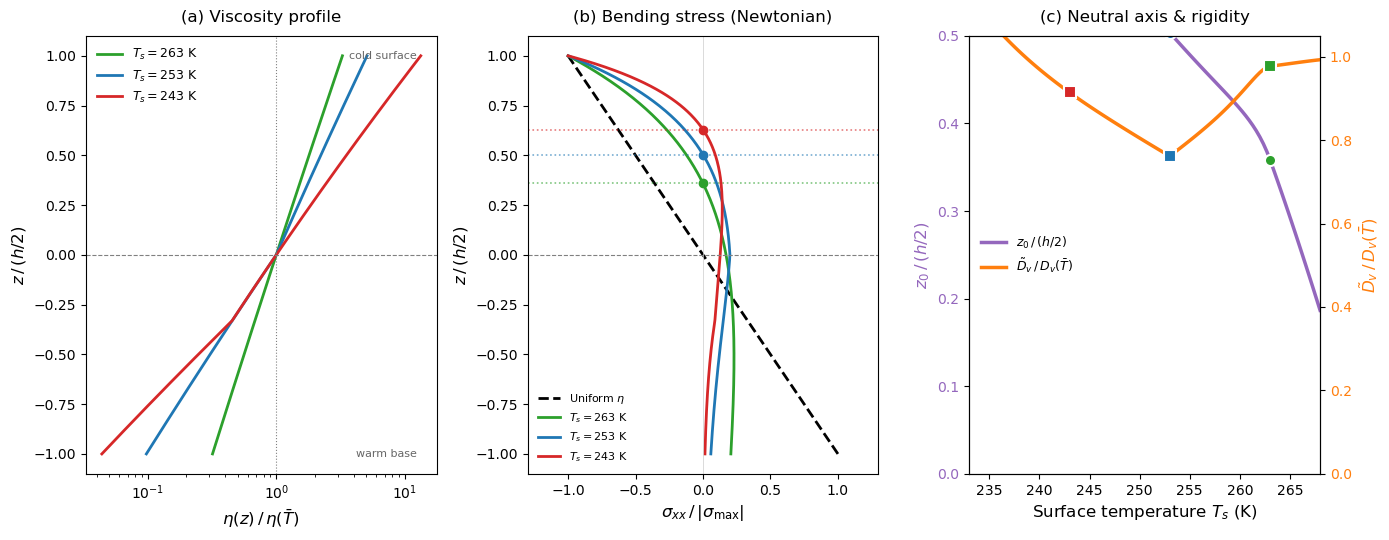

Figure 10 saved.

Numerical values:
  T_s = 263 K: eta_s/eta_b = 10, z_0/(h/2) = 0.359, D_tilde/D(T_bar) = 0.977
  T_s = 253 K: eta_s/eta_b = 52, z_0/(h/2) = 0.504, D_tilde/D(T_bar) = 0.762
  T_s = 243 K: eta_s/eta_b = 304, z_0/(h/2) = 0.629, D_tilde/D(T_bar) = 0.914


In [12]:
# ---- Fig 10: Depth-dependent temperature effect on viscous bending ----
from scipy.integrate import quad
from scipy.optimize import brentq

T_b = 273.0  # K, basal temperature (pressure melting)

def eta_profile(z_norm, T_s, T_b=273.0):
    """Newtonian viscosity profile eta(z) / eta_0, where z_norm = z/(h/2) in [-1, 1].

    z_norm = +1 is the cold surface, z_norm = -1 is the warm base.
    Returns eta(z) = 1/(2*A(T(z))) normalized by eta at the mean temperature.
    """
    T_bar = (T_s + T_b) / 2
    # T(z) = T_bar + G*z, with G = (T_s - T_b)/h and z = z_norm * h/2
    # So T(z_norm) = T_bar + (T_s - T_b)/2 * z_norm
    T_z = T_bar + (T_s - T_b) / 2 * z_norm
    # eta propto 1/A(T), so eta(z)/eta(T_bar) = A(T_bar)/A(T(z))
    return A_at_T(T_bar) / A_at_T(T_z)

def compute_z0_newtonian(T_s, T_b=273.0):
    """Neutral axis position z_0/(h/2) for Newtonian beam with depth-dependent eta."""
    num, _ = quad(lambda z: eta_profile(z, T_s, T_b) * z, -1, 1)
    den, _ = quad(lambda z: eta_profile(z, T_s, T_b), -1, 1)
    return num / den

def compute_Dv_ratio(T_s, T_b=273.0):
    """Ratio D_tilde_v / D_v(T_bar) for Newtonian beam.

    D_tilde_v = 3 * int eta(z) (z - z0)^2 dz  (beam case)
    D_v(T_bar) = 3 * eta(T_bar) * int z^2 dz = 3 * eta(T_bar) * (h/2)^3 * 2/3
    In normalized coords: D_v(T_bar) propto int_-1^1 z^2 dz = 2/3
    D_tilde_v propto int_-1^1 eta_norm(z) (z - z0)^2 dz
    """
    z0 = compute_z0_newtonian(T_s, T_b)
    Dv_tilde, _ = quad(lambda z: eta_profile(z, T_s, T_b) * (z - z0)**2, -1, 1)
    Dv_uniform = 2.0 / 3.0  # int_-1^1 z^2 dz with eta_norm = 1
    return Dv_tilde / Dv_uniform

# =====================================================================
# Surface temperatures to plot
# =====================================================================
T_s_cases = [263, 253, 243]
colors_T = ['#2ca02c', '#1f77b4', '#d62728']
labels_T = ['$T_s = 263$ K', '$T_s = 253$ K', '$T_s = 243$ K']

z_norm = np.linspace(-1, 1, 500)

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5))

# =====================================================================
# (a) Viscosity profiles
# =====================================================================
ax = axes[0]
for T_s, col, lab in zip(T_s_cases, colors_T, labels_T):
    eta_n = eta_profile(z_norm, T_s, T_b)
    ax.plot(eta_n, z_norm, '-', color=col, lw=2, label=lab)

ax.axhline(0, color='0.5', ls='--', lw=0.8)
ax.axvline(1, color='0.5', ls=':', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel(r'$\eta(z) \,/\, \eta(\bar{T})$', fontsize=12)
ax.set_ylabel(r'$z \,/\, (h/2)$', fontsize=12)
ax.set_title('(a) Viscosity profile', fontsize=12, pad=10)
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=9, frameon=False, loc='upper left')

ax.text(ax.get_xlim()[1] * 0.7, 1.0, 'cold surface', fontsize=8,
        color='0.4', ha='right', va='center')
ax.text(ax.get_xlim()[1] * 0.7, -1.0, 'warm base', fontsize=8,
        color='0.4', ha='right', va='center')

# =====================================================================
# (b) Bending stress profiles
# =====================================================================
ax = axes[1]

# Uniform case (reference): sigma propto -z
stress_uniform = -z_norm
ax.plot(stress_uniform / np.max(np.abs(stress_uniform)), z_norm,
        'k--', lw=2, label=r'Uniform $\eta$')

for T_s, col, lab in zip(T_s_cases, colors_T, labels_T):
    z0 = compute_z0_newtonian(T_s, T_b)
    # sigma_xx(z) = -3 eta(z) (z - z0) kappa_dot
    # Normalize by maximum absolute value
    stress = -eta_profile(z_norm, T_s, T_b) * (z_norm - z0)
    stress_normed = stress / np.max(np.abs(stress))
    ax.plot(stress_normed, z_norm, '-', color=col, lw=2, label=lab)
    # Mark neutral axis
    ax.axhline(z0, color=col, ls=':', lw=1.2, alpha=0.6)
    ax.plot(0, z0, 'o', color=col, ms=6, zorder=5)

ax.axhline(0, color='0.5', ls='--', lw=0.8)
ax.axvline(0, color='0.8', ls='-', lw=0.5)
ax.set_xlabel(r'$\sigma_{xx} \,/\, |\sigma_{\max}|$', fontsize=12)
ax.set_ylabel(r'$z \,/\, (h/2)$', fontsize=12)
ax.set_title('(b) Bending stress (Newtonian)', fontsize=12, pad=10)
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.1, 1.1)
ax.legend(fontsize=8, frameon=False, loc='lower left')

# =====================================================================
# (c) z0 and D_v ratio vs T_s
# =====================================================================
ax = axes[2]

T_s_sweep = np.linspace(233, 268, 100)
z0_sweep = np.array([compute_z0_newtonian(T_s, T_b) for T_s in T_s_sweep])
Dv_ratio_sweep = np.array([compute_Dv_ratio(T_s, T_b) for T_s in T_s_sweep])

ax.plot(T_s_sweep, z0_sweep, '-', color='#9467bd', lw=2.5,
        label=r'$z_0 \,/\, (h/2)$')
ax.set_xlabel(r'Surface temperature $T_s$ (K)', fontsize=12)
ax.set_ylabel(r'$z_0 \,/\, (h/2)$', fontsize=12, color='#9467bd')
ax.tick_params(axis='y', labelcolor='#9467bd')
ax.set_ylim(0, 0.5)
ax.set_xlim(233, 268)

ax2 = ax.twinx()
ax2.plot(T_s_sweep, Dv_ratio_sweep, '-', color='#ff7f0e', lw=2.5,
         label=r'$\tilde{D}_v \,/\, D_v(\bar{T})$')
ax2.set_ylabel(r'$\tilde{D}_v \,/\, D_v(\bar{T})$', fontsize=12, color='#ff7f0e')
ax2.tick_params(axis='y', labelcolor='#ff7f0e')
ax2.set_ylim(0, 1.05)

# Mark the three example cases
for T_s, col in zip(T_s_cases, colors_T):
    z0_val = compute_z0_newtonian(T_s, T_b)
    Dv_val = compute_Dv_ratio(T_s, T_b)
    ax.plot(T_s, z0_val, 'o', color=col, ms=8, zorder=5,
            markeredgecolor='white', markeredgewidth=1.5)
    ax2.plot(T_s, Dv_val, 's', color=col, ms=8, zorder=5,
             markeredgecolor='white', markeredgewidth=1.5)

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, frameon=False, loc='center left')

ax.set_title('(c) Neutral axis & rigidity', fontsize=12, pad=10)

fig.tight_layout()
fig.savefig('figures/fig10_depth_dependent_temperature.pdf', bbox_inches='tight')
fig.savefig('figures/fig10_depth_dependent_temperature.png', dpi=200, bbox_inches='tight')
plt.show()

# Print numerical values for reference
print('Figure 10 saved.\n')
print('Numerical values:')
for T_s in T_s_cases:
    z0 = compute_z0_newtonian(T_s, T_b)
    Dv = compute_Dv_ratio(T_s, T_b)
    eta_ratio = A_at_T(T_b) / A_at_T(T_s)
    print(f'  T_s = {T_s} K: eta_s/eta_b = {eta_ratio:.0f}, '
          f'z_0/(h/2) = {z0:.3f}, D_tilde/D(T_bar) = {Dv:.3f}')

---
## Figure 11: Maxwell Viscoelastic Tidal Flexure — Deborah Number Sweep

Solve the 1D viscoelastic flexure equation (Appendix F) for a floating beam clamped at the grounding line under monochromatic tidal forcing, sweeping through Deborah numbers from $\text{De} \ll 1$ (viscous limit) to $\text{De} \gg 1$ (elastic limit).  The FEM solver from `viscoelastic_beam_solvers.py` implements the full Maxwell viscoelastic beam equation:

$$D_v\,\nabla^4 \dot{w} + \rho_w g\,w + \frac{D_v}{D}\,\rho_w g\,\dot{w} = q + \frac{D_v}{D}\,\dot{q}$$

Four panels: (a) deflection profiles at peak tide for several De values, (b) curvature profiles, (c) phase lag $\varphi(x)$ relative to the tide, and (d) time series at $x = \ell_f$ showing the transition from lagged viscous response to in-phase elastic response.

In [13]:
# ---- Fig 11: Viscoelastic tidal flexure — Deborah number sweep ----
from viscoelastic_beam_solvers import (
    HermiteFEMBeam, run_viscoelastic_tidal, deborah_sweep,
    viscoelastic_analytical, viscoelastic_analytical_curvature,
    viscoelastic_complex_amplitude, solve_wdot_viscoelastic,
)

# Parameters (reuse from earlier cells)
h_ve = 500.0
w0_ve = 1.0
T_tide_ve = 12 * 3600.0
omega_ve = 2 * np.pi / T_tide_ve

D_el_ve = E * h_ve**3 / (12 * (1 - nu**2))
ell_f_ve = (4 * D_el_ve / (rho_w * g))**0.25

# FEM mesh
L_ve = 10 * ell_f_ve
Nel_ve = 80
fem_ve = HermiteFEMBeam(L_ve, Nel_ve)
x_ve = fem_ve.x_nodes

# Deborah number sweep: viscosities spanning De ~ 0.01 to De ~ 100
# De = eta / (mu * T_tide)
De_targets = np.array([0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 100.0])
eta_sweep = De_targets * mu * T_tide_ve

print('Running Deborah number sweep...')
print(f'  De targets: {De_targets}')
print(f'  eta range: {eta_sweep[0]:.2e} -- {eta_sweep[-1]:.2e} Pa s')

ve_results = deborah_sweep(
    fem_ve, eta_sweep, mu, h_ve, E, nu, w0_ve, omega_ve, rho_w, g,
    dt=30.0, n_cycles=6,
)

# Also compute elastic reference
def elastic_flexure_ve(x, t):
    xi = x / ell_f_ve
    return w0_ve * np.sin(omega_ve * t) * (1 - np.exp(-xi) * (np.cos(xi) + np.sin(xi)))

def elastic_curvature_ve(x, t):
    xi = x / ell_f_ve
    return w0_ve * np.sin(omega_ve * t) * 2 * np.exp(-xi) * (np.cos(xi) - np.sin(xi)) / ell_f_ve**2

print('Done.')
for r in ve_results:
    print(f"  De = {r['De']:.2f}, eta = {r['eta']:.2e}, "
          f"max|w| = {np.max(np.abs(r['w_hist'])):.3f}")

Running Deborah number sweep...
  De targets: [1.e-02 3.e-02 1.e-01 3.e-01 1.e+00 3.e+00 1.e+01 1.e+02]
  eta range: 1.52e+12 -- 1.52e+16 Pa s


Done.
  De = 0.01, eta = 1.52e+12, max|w| = 1.127
  De = 0.03, eta = 4.56e+12, max|w| = 1.105
  De = 0.10, eta = 1.52e+13, max|w| = 1.066
  De = 0.30, eta = 4.56e+13, max|w| = 1.047
  De = 1.00, eta = 1.52e+14, max|w| = 1.044
  De = 3.00, eta = 4.56e+14, max|w| = 1.043
  De = 10.00, eta = 1.52e+15, max|w| = 1.045
  De = 100.00, eta = 1.52e+16, max|w| = 1.045


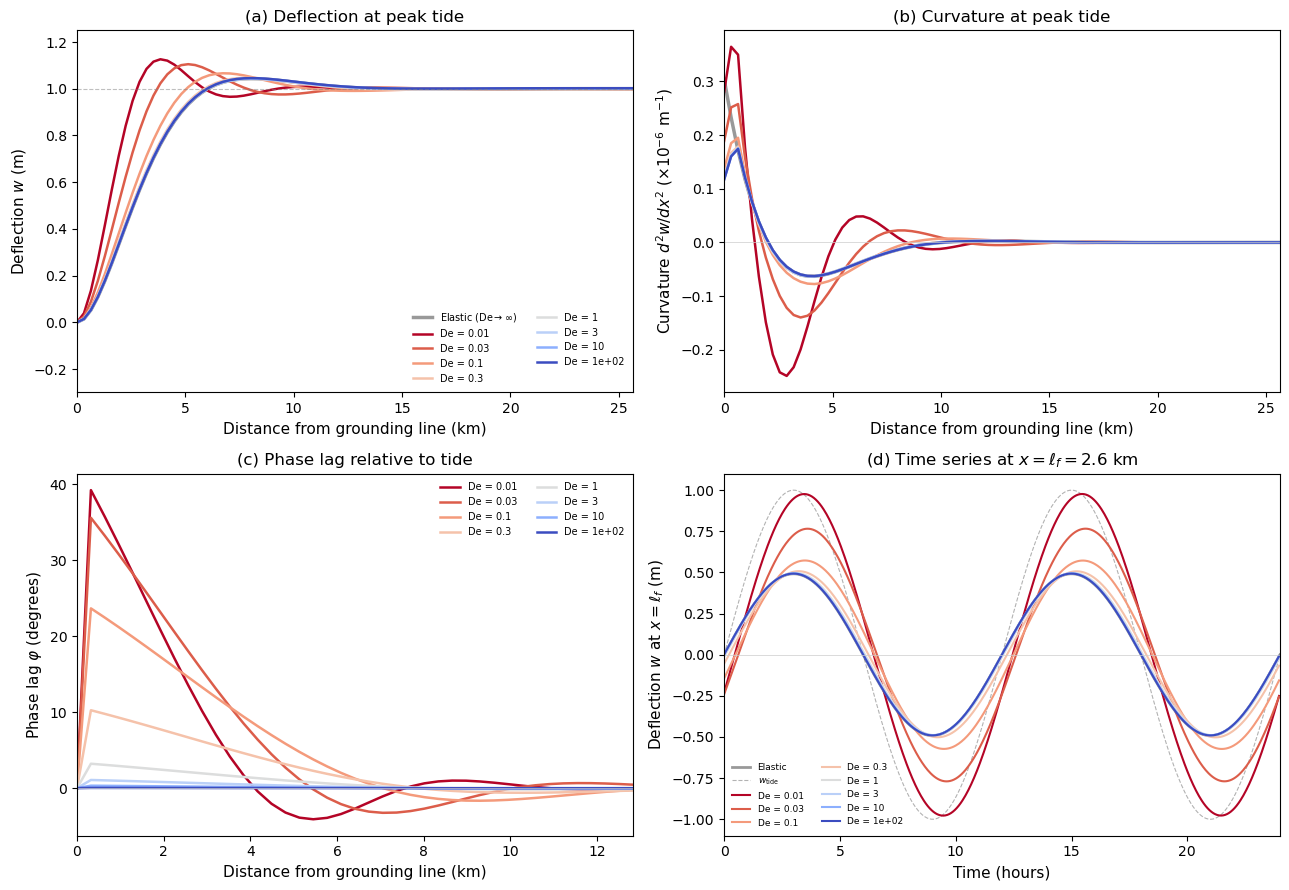

Saved fig11_viscoelastic_flexure_De_sweep.pdf/png


In [14]:
# ---- Fig 11: Plotting ----
cmap_de = plt.cm.coolwarm_r
De_for_color = np.log10(np.array([r['De'] for r in ve_results]))
De_min, De_max = De_for_color.min(), De_for_color.max()
norm_de = plt.Normalize(De_min, De_max)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) Deflection at peak tide
ax = axes[0, 0]
# Elastic reference
ax.plot(x_ve / 1e3, elastic_flexure_ve(x_ve, T_tide_ve / 4),
        'k-', lw=2.5, alpha=0.4, label='Elastic ($\\text{De} \\to \\infty$)')
for r in ve_results:
    phase = omega_ve * r['t_hist']
    idx = np.argmax(np.sin(phase))
    color = cmap_de(norm_de(np.log10(r['De'])))
    ax.plot(x_ve / 1e3, r['w_hist'][idx], '-', color=color, lw=1.8,
            label=f'De = {r["De"]:.2g}')
ax.axhline(w0_ve, color='gray', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('Distance from grounding line (km)', fontsize=11)
ax.set_ylabel('Deflection $w$ (m)', fontsize=11)
ax.set_title('(a) Deflection at peak tide', fontsize=12)
ax.set_xlim(0, L_ve / 1e3)
ax.set_ylim(-0.3, 1.25)
ax.legend(fontsize=7, frameon=False, ncol=2, loc='lower right')

# (b) Curvature at peak tide
ax = axes[0, 1]
ax.plot(x_ve / 1e3, elastic_curvature_ve(x_ve, T_tide_ve / 4) * 1e6,
        'k-', lw=2.5, alpha=0.4, label='Elastic')
for r in ve_results:
    phase = omega_ve * r['t_hist']
    idx = np.argmax(np.sin(phase))
    kappa = np.gradient(np.gradient(r['w_hist'][idx], x_ve), x_ve)
    color = cmap_de(norm_de(np.log10(r['De'])))
    ax.plot(x_ve / 1e3, kappa * 1e6, '-', color=color, lw=1.8)
ax.axhline(0, color='0.8', ls='-', lw=0.5)
ax.set_xlabel('Distance from grounding line (km)', fontsize=11)
ax.set_ylabel('Curvature $d^2w/dx^2$ ($\\times 10^{-6}$ m$^{-1}$)', fontsize=11)
ax.set_title('(b) Curvature at peak tide', fontsize=12)
ax.set_xlim(0, L_ve / 1e3)

# (c) Phase lag from analytical solution
ax = axes[1, 0]
for r in ve_results:
    W = viscoelastic_complex_amplitude(
        x_ve, w0_ve, r['D_v'], D_el_ve, omega_ve, rho_w, g
    )
    phi = -np.angle(W)  # phase lag
    phi_deg = np.degrees(phi)
    color = cmap_de(norm_de(np.log10(r['De'])))
    ax.plot(x_ve / 1e3, phi_deg, '-', color=color, lw=1.8,
            label=f'De = {r["De"]:.2g}')
ax.axhline(0, color='0.8', ls='-', lw=0.5)
ax.set_xlabel('Distance from grounding line (km)', fontsize=11)
ax.set_ylabel('Phase lag $\\varphi$ (degrees)', fontsize=11)
ax.set_title('(c) Phase lag relative to tide', fontsize=12)
ax.set_xlim(0, 5 * ell_f_ve / 1e3)
ax.legend(fontsize=7, frameon=False, ncol=2)

# (d) Time series at x = ell_f
ax = axes[1, 1]
ix_probe = np.argmin(np.abs(x_ve - ell_f_ve))
t_ts = np.linspace(0, 2 * T_tide_ve, 500)
ax.plot(t_ts / 3600, elastic_flexure_ve(ell_f_ve, t_ts),
        'k-', lw=2, alpha=0.4, label='Elastic')
ax.plot(t_ts / 3600, w0_ve * np.sin(omega_ve * t_ts),
        'k--', lw=0.8, alpha=0.3, label='$w_{\\mathrm{tide}}$')
# Run 2 extra cycles from the spun-up state for time-series plotting
dt_ts = 30.0
for r in ve_results:
    D_v_r = r['D_v']
    t_relax_r = r['t_relax']
    w_run = r['w_final'].copy()
    w_ts_list = []; t_ts_list = []
    steps_2cyc = int(2 * T_tide_ve / dt_ts)
    for step in range(steps_2cyc):
        t_curr = step * dt_ts
        w_tide_now = w0_ve * np.sin(omega_ve * t_curr)
        dw_tide_now = w0_ve * omega_ve * np.cos(omega_ve * t_curr)
        wdot = solve_wdot_viscoelastic(
            fem_ve, w_run, w_tide_now, dw_tide_now,
            D_v_r, dt_ts, rho_w, g, t_relax=t_relax_r,
        )
        w_run = w_run + dt_ts * wdot[0::2]
        w_run[0] = 0.0
        if step % max(1, steps_2cyc // 500) == 0:
            w_ts_list.append(w_run[ix_probe])
            t_ts_list.append(t_curr)
    color = cmap_de(norm_de(np.log10(r['De'])))
    ax.plot(np.array(t_ts_list) / 3600, w_ts_list, '-', color=color, lw=1.5,
            label=f'De = {r["De"]:.2g}')
ax.axhline(0, color='0.8', ls='-', lw=0.5)
ax.set_xlabel('Time (hours)', fontsize=11)
ax.set_ylabel(f'Deflection $w$ at $x = \\ell_f$ (m)', fontsize=11)
ax.set_title(f'(d) Time series at $x = \\ell_f = {ell_f_ve/1e3:.1f}$ km', fontsize=12)
ax.set_xlim(0, 2 * T_tide_ve / 3600)
ax.legend(fontsize=6.5, frameon=False, ncol=2)

fig.tight_layout()
fig.savefig('figures/fig11_viscoelastic_flexure_De_sweep.pdf', bbox_inches='tight')
fig.savefig('figures/fig11_viscoelastic_flexure_De_sweep.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig11_viscoelastic_flexure_De_sweep.pdf/png')

---
## Figure 12: FEM vs Analytical Validation and Amplitude/Phase Summary

Two panels: (a) FEM vs analytical deflection at peak tide for a representative De, validating the numerical solution against the closed-form Newtonian viscoelastic result. (b) Far-field amplitude ratio $|W(\ell_f)| / w_0$ and phase lag $\varphi(\ell_f)$ as continuous functions of De, showing the smooth transition from viscous to elastic behavior.

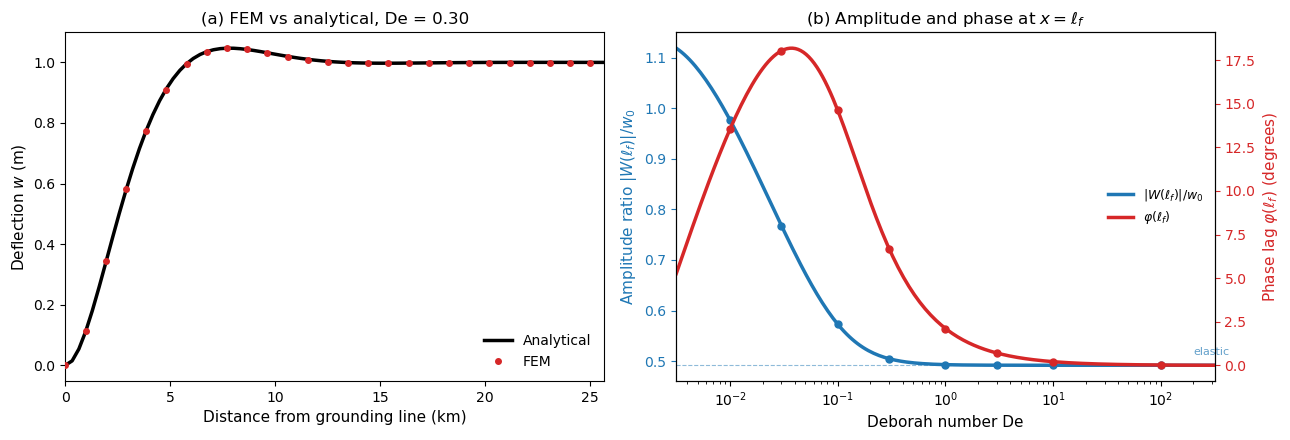

Saved fig12_viscoelastic_validation_summary.pdf/png


In [15]:
# ---- Fig 12: Validation and amplitude/phase vs De ----
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) FEM vs analytical for a representative De
# Pick De ~ 0.3 case
idx_rep = np.argmin(np.abs(np.array([r['De'] for r in ve_results]) - 0.3))
r_rep = ve_results[idx_rep]
De_rep = r_rep['De']
phase = omega_ve * r_rep['t_hist']
idx_peak = np.argmax(np.sin(phase))
t_peak = r_rep['t_hist'][idx_peak]

w_fem = r_rep['w_hist'][idx_peak]
w_ana = viscoelastic_analytical(
    x_ve, t_peak, w0_ve, r_rep['D_v'], D_el_ve, omega_ve, rho_w, g
)

ax1.plot(x_ve / 1e3, w_ana, 'k-', lw=2.5, label='Analytical')
ax1.plot(x_ve / 1e3, w_fem, 'o', color='#d62728', ms=4, markevery=3,
         label='FEM', zorder=5)
ax1.set_xlabel('Distance from grounding line (km)', fontsize=11)
ax1.set_ylabel('Deflection $w$ (m)', fontsize=11)
ax1.set_title(f'(a) FEM vs analytical, De = {De_rep:.2f}', fontsize=12)
ax1.set_xlim(0, L_ve / 1e3)
ax1.legend(fontsize=10, frameon=False)

# (b) Amplitude ratio and phase lag at x = ell_f as function of De
De_cont = np.logspace(-2.5, 2.5, 200)
eta_cont = De_cont * mu * T_tide_ve
amp_ratio = np.zeros_like(De_cont)
phi_at_ell = np.zeros_like(De_cont)

for i, (de, et) in enumerate(zip(De_cont, eta_cont)):
    Dv_i = et * h_ve**3 / 3
    W = viscoelastic_complex_amplitude(
        np.array([ell_f_ve]), w0_ve, Dv_i, D_el_ve, omega_ve, rho_w, g
    )
    amp_ratio[i] = np.abs(W[0]) / w0_ve
    phi_at_ell[i] = -np.degrees(np.angle(W[0]))

color_amp = '#1f77b4'
color_phi = '#d62728'

ax2.semilogx(De_cont, amp_ratio, '-', color=color_amp, lw=2.5,
             label='$|W(\\ell_f)| / w_0$')
ax2.set_xlabel('Deborah number De', fontsize=11)
ax2.set_ylabel('Amplitude ratio $|W(\\ell_f)| / w_0$', fontsize=11, color=color_amp)
ax2.tick_params(axis='y', colors=color_amp)

# Elastic limit amplitude
xi_elf = 1.0  # x = ell_f => xi = 1
w_el_at_elf = 1 - np.exp(-xi_elf) * (np.cos(xi_elf) + np.sin(xi_elf))
ax2.axhline(w_el_at_elf, color=color_amp, ls='--', lw=0.8, alpha=0.5)
ax2.text(200, w_el_at_elf + 0.02, 'elastic', fontsize=8, color=color_amp, alpha=0.7)

ax2b = ax2.twinx()
ax2b.semilogx(De_cont, phi_at_ell, '-', color=color_phi, lw=2.5,
              label='$\\varphi(\\ell_f)$')
ax2b.set_ylabel('Phase lag $\\varphi(\\ell_f)$ (degrees)', fontsize=11, color=color_phi)
ax2b.tick_params(axis='y', colors=color_phi)

# Mark FEM results
for r in ve_results:
    W_check = viscoelastic_complex_amplitude(
        np.array([ell_f_ve]), w0_ve, r['D_v'], D_el_ve, omega_ve, rho_w, g
    )
    ax2.plot(r['De'], np.abs(W_check[0]) / w0_ve, 'o', color=color_amp,
             ms=5, zorder=5)
    ax2b.plot(r['De'], -np.degrees(np.angle(W_check[0])), 'o', color=color_phi,
              ms=5, zorder=5)

ax2.set_title('(b) Amplitude and phase at $x = \\ell_f$', fontsize=12)
ax2.set_xlim(De_cont[0], De_cont[-1])

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=9, frameon=False, loc='center right')

fig.tight_layout()
fig.savefig('figures/fig12_viscoelastic_validation_summary.pdf', bbox_inches='tight')
fig.savefig('figures/fig12_viscoelastic_validation_summary.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig12_viscoelastic_validation_summary.pdf/png')

---
## Figure 13: Power-Law Viscoelastic Flexure — Effect of Flow Law Exponent

Compare the viscoelastic tidal flexure response across rheologies ($n = 1, 1.8, 4$) and Deborah numbers. For $n > 1$ the effective viscosity at the background curvature rate is matched to the Newtonian $D_v$, so differences arise from the strain-rate dependence of viscosity during bending. Panel (a) shows deflection profiles at peak tide for De = 1; panel (b) shows the amplitude ratio and phase lag at $x = \ell_f$ as functions of De.

In [16]:
# ---- Fig 13: Power-law viscoelastic — computation ----

eps_bg_13 = 1e-10
kappa_bg_13 = eps_bg_13 / (h_ve / 2)

De_targets_13 = np.array([0.01, 0.1, 1.0, 10.0, 100.0])
n_values_13 = [1, 1.8, 4]

ix_probe_13 = np.argmin(np.abs(x_ve - ell_f_ve))

def extract_amp_phase(w_hist, t_hist, omega, probe_idx):
    """Extract fundamental amplitude and phase lag at a probe node."""
    w = w_hist[:, probe_idx]
    T = 2 * np.pi / omega
    a_s = (2/T) * np.trapezoid(w * np.sin(omega * t_hist), t_hist)
    a_c = (2/T) * np.trapezoid(w * np.cos(omega * t_hist), t_hist)
    amp = np.sqrt(a_s**2 + a_c**2)
    phi = np.arctan2(-a_c, a_s)
    return amp, np.degrees(phi)

def A_from_matched_Dv(D_v, n, h, kappa_bg):
    """Recover Glen A so that D_eff(kappa_bg) = D_v."""
    D_n = D_v * kappa_bg**(1 - 1.0/n)
    B = D_n * (1 + 2*n) / (2*n) / (h/2)**((1.0/n) + 2)
    return (2.0 / B)**n

print('Running power-law viscoelastic sweep...')
results_13 = {}
for n_val in n_values_13:
    for De in De_targets_13:
        eta_i = De * mu * T_tide_ve
        D_v_i = eta_i * h_ve**3 / 3

        kwargs = dict(dt=30.0, n_cycles=8, save_last_n_cycles=1)
        if n_val == 1:
            res = run_viscoelastic_tidal(
                fem_ve, D_v_i, D_el_ve, w0_ve, omega_ve, rho_w, g, **kwargs)
        else:
            A_gl = A_from_matched_Dv(D_v_i, n_val, h_ve, kappa_bg_13)
            res = run_viscoelastic_tidal(
                fem_ve, D_v_i, D_el_ve, w0_ve, omega_ve, rho_w, g,
                n_nl=n_val, A_glen=A_gl, h_plate=h_ve, kappa_bg=kappa_bg_13,
                **kwargs)

        amp, phi = extract_amp_phase(
            res['w_hist'], res['t_hist'], omega_ve, ix_probe_13)
        res['amp_ratio'] = amp / w0_ve
        res['phase_deg'] = phi
        res['De'] = De
        res['D_v'] = D_v_i
        results_13[(n_val, De)] = res
        print(f'  n={n_val}, De={De:.2g}: amp/w0={amp/w0_ve:.3f}, '
              f'phi={phi:.1f} deg')

print('Done.')

Running power-law viscoelastic sweep...


  n=1, De=0.01: amp/w0=0.977, phi=13.5 deg


  n=1, De=0.1: amp/w0=0.572, phi=14.5 deg


  n=1, De=1: amp/w0=0.493, phi=2.0 deg


  n=1, De=10: amp/w0=0.492, phi=0.1 deg


...

  n=4, De=0.01: amp/w0=0.976, phi=0.2 deg


  n=4, De=0.1: amp/w0=1.081, phi=0.9 deg


  n=4, De=1: amp/w0=0.828, phi=4.8 deg


  n=4, De=10: amp/w0=0.777, phi=0.5 deg


  n=4, De=1e+02: amp/w0=0.777, phi=-0.1 deg
Done.


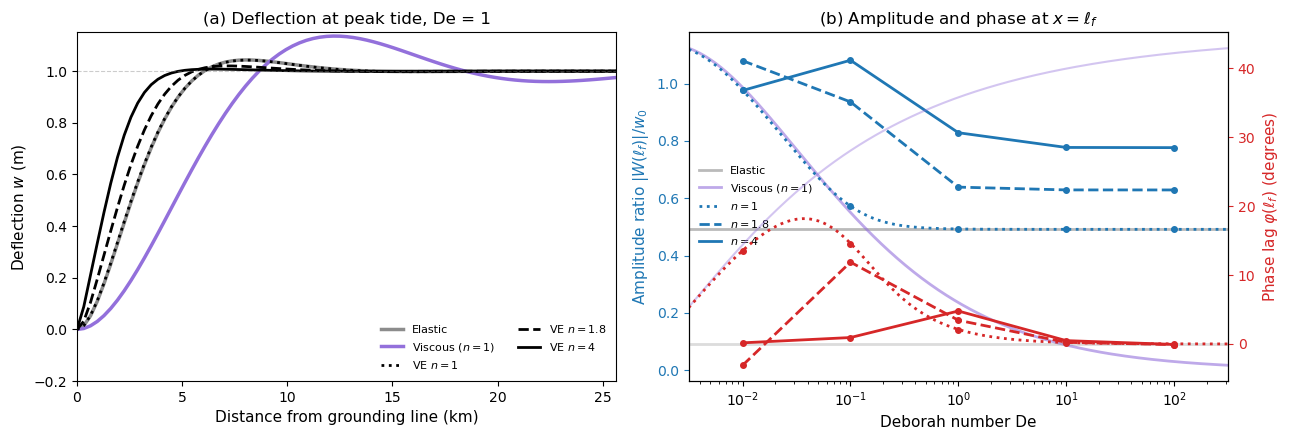

Saved fig13_powerlaw_viscoelastic.pdf/png


In [17]:
# ---- Fig 13: Plotting ----
color_amp = '#1f77b4'
color_phi = '#d62728'
color_el = '0.55'
color_visc = 'mediumpurple'
lstyles = {1: ':', 1.8: '--', 4: '-'}
nlabels = {1: '$n=1$', 1.8: '$n=1.8$', 4: '$n=4$'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# ---- Panel (a): Deflection at peak tide for De = 1 ----
De_show = 1.0

# Elastic reference
xi_ve = x_ve / ell_f_ve
w_el_peak = w0_ve * (1 - np.exp(-xi_ve) * (np.cos(xi_ve) + np.sin(xi_ve)))
ax1.plot(x_ve / 1e3, w_el_peak, '-', color=color_el, lw=2.5,
         label='Elastic', zorder=1)

# Pure viscous (n=1) reference at same D_v
D_v_show = De_show * mu * T_tide_ve * h_ve**3 / 3
W_visc = viscoelastic_complex_amplitude(
    x_ve, w0_ve, D_v_show, 1e30, omega_ve, rho_w, g)
# Find time of peak for viscous solution (it's phase-shifted)
t_visc_peak = (np.pi/2 + np.angle(W_visc[-1])) / omega_ve
w_visc_peak = np.imag(W_visc * np.exp(1j * omega_ve * t_visc_peak))
ax1.plot(x_ve / 1e3, w_visc_peak, '-', color=color_visc, lw=2.5,
         label='Viscous ($n=1$)', zorder=1)

# Viscoelastic for each n
for n_val in n_values_13:
    r = results_13[(n_val, De_show)]
    phase = omega_ve * r['t_hist']
    idx = np.argmax(np.sin(phase))
    ax1.plot(x_ve / 1e3, r['w_hist'][idx], lstyles[n_val],
             color='k', lw=2, label=f'VE {nlabels[n_val]}', zorder=2)

ax1.axhline(w0_ve, color='gray', ls='--', lw=0.8, alpha=0.4)
ax1.set_xlabel('Distance from grounding line (km)', fontsize=11)
ax1.set_ylabel('Deflection $w$ (m)', fontsize=11)
ax1.set_title('(a) Deflection at peak tide, De = 1', fontsize=12)
ax1.set_xlim(0, L_ve / 1e3)
ax1.set_ylim(-0.2, 1.15)
ax1.legend(fontsize=8, frameon=False, ncol=2)

# ---- Panel (b): Amplitude and phase at x = ell_f vs De ----

# Continuous analytical curves for n=1 VE and pure viscous
De_fine = np.logspace(-2.5, 2.5, 200)
eta_fine = De_fine * mu * T_tide_ve

amp_n1_ve = np.zeros_like(De_fine)
phi_n1_ve = np.zeros_like(De_fine)
amp_visc_ref = np.zeros_like(De_fine)
phi_visc_ref = np.zeros_like(De_fine)

for i, et in enumerate(eta_fine):
    D_v_i = et * h_ve**3 / 3
    # n=1 viscoelastic
    W_ve = viscoelastic_complex_amplitude(
        np.array([ell_f_ve]), w0_ve, D_v_i, D_el_ve, omega_ve, rho_w, g)
    amp_n1_ve[i] = np.abs(W_ve[0]) / w0_ve
    phi_n1_ve[i] = -np.degrees(np.angle(W_ve[0]))
    # Pure viscous (n=1, D_el -> inf)
    W_pv = viscoelastic_complex_amplitude(
        np.array([ell_f_ve]), w0_ve, D_v_i, 1e30, omega_ve, rho_w, g)
    amp_visc_ref[i] = np.abs(W_pv[0]) / w0_ve
    phi_visc_ref[i] = -np.degrees(np.angle(W_pv[0]))

# Elastic limit
xi1 = 1.0
amp_elastic = 1 - np.exp(-xi1) * (np.cos(xi1) + np.sin(xi1))

# Plot amplitude (blue, left axis)
ax2.axhline(amp_elastic, color=color_el, ls='-', lw=2, alpha=0.6,
            label='Elastic', zorder=1)
ax2.semilogx(De_fine, amp_visc_ref, '-', color=color_visc, lw=2, alpha=0.6,
             label='Viscous ($n=1$)', zorder=1)

for n_val in n_values_13:
    De_pts = De_targets_13
    amp_pts = [results_13[(n_val, d)]['amp_ratio'] for d in De_pts]
    if n_val == 1:
        # Smooth analytical curve
        ax2.semilogx(De_fine, amp_n1_ve, lstyles[n_val],
                     color=color_amp, lw=2, label=nlabels[n_val])
    else:
        ax2.semilogx(De_pts, amp_pts, lstyles[n_val],
                     color=color_amp, lw=2, label=nlabels[n_val])
    # FEM markers for all n
    ax2.plot(De_pts, amp_pts, 'o', color=color_amp, ms=4, zorder=5)

ax2.set_xlabel('Deborah number De', fontsize=11)
ax2.set_ylabel('Amplitude ratio $|W(\\ell_f)| / w_0$',
               fontsize=11, color=color_amp)
ax2.tick_params(axis='y', colors=color_amp)
ax2.set_xlim(De_fine[0], De_fine[-1])

# Plot phase (red, right axis)
ax2b = ax2.twinx()
ax2b.axhline(0, color=color_el, ls='-', lw=2, alpha=0.3, zorder=0)
ax2b.semilogx(De_fine, phi_visc_ref, '-', color=color_visc, lw=1.5,
              alpha=0.4, zorder=1)

for n_val in n_values_13:
    De_pts = De_targets_13
    phi_pts = [results_13[(n_val, d)]['phase_deg'] for d in De_pts]
    if n_val == 1:
        ax2b.semilogx(De_fine, phi_n1_ve, lstyles[n_val],
                     color=color_phi, lw=2)
    else:
        ax2b.semilogx(De_pts, phi_pts, lstyles[n_val],
                     color=color_phi, lw=2)
    ax2b.plot(De_pts, phi_pts, 'o', color=color_phi, ms=4, zorder=5)

ax2b.set_ylabel('Phase lag $\\varphi(\\ell_f)$ (degrees)',
                fontsize=11, color=color_phi)
ax2b.tick_params(axis='y', colors=color_phi)

ax2.set_title('(b) Amplitude and phase at $x = \\ell_f$', fontsize=12)

# Combined legend (from left axis only)
ax2.legend(fontsize=8, frameon=False, loc='center left')

fig.tight_layout()
fig.savefig('figures/fig13_powerlaw_viscoelastic.pdf', bbox_inches='tight')
fig.savefig('figures/fig13_powerlaw_viscoelastic.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig13_powerlaw_viscoelastic.pdf/png')

---
## Figure 14: Power-Law Viscoelastic Tidal Flexure — 4-Panel Sweep

Four-panel figure analogous to Figure 11 but comparing three flow law exponents ($n = 1, 1.8, 4$) across Deborah numbers De = 0.01–100. Line styles: dotted ($n=1$), dashed ($n=1.8$), solid ($n=4$). Colors encode De via the same coolwarm colormap as Figure 11. Grey = elastic reference, light purple = pure Newtonian viscous reference.

In [18]:
# ---- Fig 14: Power-law viscoelastic 4-panel sweep ----
from viscoelastic_beam_solvers import solve_wdot_viscoelastic_powerlaw

eps_bg_14 = 1e-10
kappa_bg_14 = eps_bg_14 / (h_ve / 2)
De_targets_14 = np.array([0.01, 0.1, 1.0, 10.0, 100.0])
n_values_14 = [1, 1.8, 4]
ix_probe_14 = np.argmin(np.abs(x_ve - ell_f_ve))

def A_from_matched_Dv_14(D_v, n, h, kbg):
    D_n = D_v * kbg**(1 - 1.0/n)
    B = D_n * (1 + 2*n) / (2*n) / (h/2)**((1.0/n) + 2)
    return (2.0 / B)**n

print('Running power-law viscoelastic sweep (4-panel)...')
results_14 = {}
for n_val in n_values_14:
    for De in De_targets_14:
        eta_i = De * mu * T_tide_ve
        D_v_i = eta_i * h_ve**3 / 3
        pi = 6 if De < 0.1 else 3
        kw = dict(dt=30.0, n_cycles=8, save_last_n_cycles=1, picard_iters=pi)
        if n_val == 1:
            res = run_viscoelastic_tidal(
                fem_ve, D_v_i, D_el_ve, w0_ve, omega_ve, rho_w, g, **kw)
        else:
            A_gl = A_from_matched_Dv_14(D_v_i, n_val, h_ve, kappa_bg_14)
            res = run_viscoelastic_tidal(
                fem_ve, D_v_i, D_el_ve, w0_ve, omega_ve, rho_w, g,
                n_nl=n_val, A_glen=A_gl, h_plate=h_ve, kappa_bg=kappa_bg_14, **kw)
        res['De'] = De; res['D_v'] = D_v_i; res['n'] = n_val
        results_14[(n_val, De)] = res
        print(f'  n={n_val}, De={De:.2g}: done')

# Extract phase lag profiles via Fourier analysis at each node
print('Extracting phase lag profiles...')
for key, res in results_14.items():
    wh = res['w_hist']; th = res['t_hist']; T = 2*np.pi/omega_ve
    phi_prof = np.zeros(wh.shape[1])
    for i in range(wh.shape[1]):
        a_s = (2/T) * np.trapezoid(wh[:,i]*np.sin(omega_ve*th), th)
        a_c = (2/T) * np.trapezoid(wh[:,i]*np.cos(omega_ve*th), th)
        phi_prof[i] = np.degrees(np.arctan2(-a_c, a_s))
    res['phi_profile'] = phi_prof

# Run 2-cycle time series for panel (d)
print('Running time series...')
dt_ts_14 = 30.0
steps_2cyc_14 = int(2 * T_tide_ve / dt_ts_14)
for n_val in n_values_14:
    for De in De_targets_14:
        r = results_14[(n_val, De)]
        D_v_i = r['D_v']; t_relax_i = D_v_i / D_el_ve
        pi = 6 if De < 0.1 else 3
        w_run = r['w_final'].copy(); wdp = None
        w_ts = []; t_ts = []
        if n_val == 1:
            for step in range(steps_2cyc_14):
                tc = step * dt_ts_14
                wt = w0_ve * np.sin(omega_ve * tc)
                dwt = w0_ve * omega_ve * np.cos(omega_ve * tc)
                wd = solve_wdot_viscoelastic(
                    fem_ve, w_run, wt, dwt, D_v_i, dt_ts_14, rho_w, g,
                    t_relax=t_relax_i)
                w_run = w_run + dt_ts_14 * wd[0::2]; w_run[0] = 0.0
                if step % max(1, steps_2cyc_14//500) == 0:
                    w_ts.append(w_run[ix_probe_14]); t_ts.append(tc)
        else:
            A_gl = A_from_matched_Dv_14(D_v_i, n_val, h_ve, kappa_bg_14)
            B_c = 2.0 / A_gl**(1.0/n_val)
            D_n = (2*n_val/(1+2*n_val)) * B_c * (h_ve/2)**((1.0/n_val)+2)
            for step in range(steps_2cyc_14):
                tc = step * dt_ts_14
                wt = w0_ve * np.sin(omega_ve * tc)
                dwt = w0_ve * omega_ve * np.cos(omega_ve * tc)
                wd = solve_wdot_viscoelastic_powerlaw(
                    fem_ve, w_run, wt, dwt, D_n, n_val, kappa_bg_14,
                    dt_ts_14, rho_w, g, D_el=D_el_ve, t_relax=t_relax_i,
                    wdot_prev=wdp, picard_iters=pi)
                wdp = wd; w_run = w_run + dt_ts_14 * wd[0::2]; w_run[0] = 0.0
                if step % max(1, steps_2cyc_14//500) == 0:
                    w_ts.append(w_run[ix_probe_14]); t_ts.append(tc)
        r['w_ts'] = np.array(w_ts); r['t_ts'] = np.array(t_ts)
        print(f'  n={n_val}, De={De:.2g}: ts done')
print('All data ready.')

Running power-law viscoelastic sweep (4-panel)...


  n=1, De=0.01: done


  n=1, De=0.1: done


  n=1, De=1: done


  n=1, De=10: done


...

  n=4, De=0.01: ts done


  n=4, De=0.1: ts done


  n=4, De=1: ts done


  n=4, De=10: ts done


  n=4, De=1e+02: ts done
All data ready.


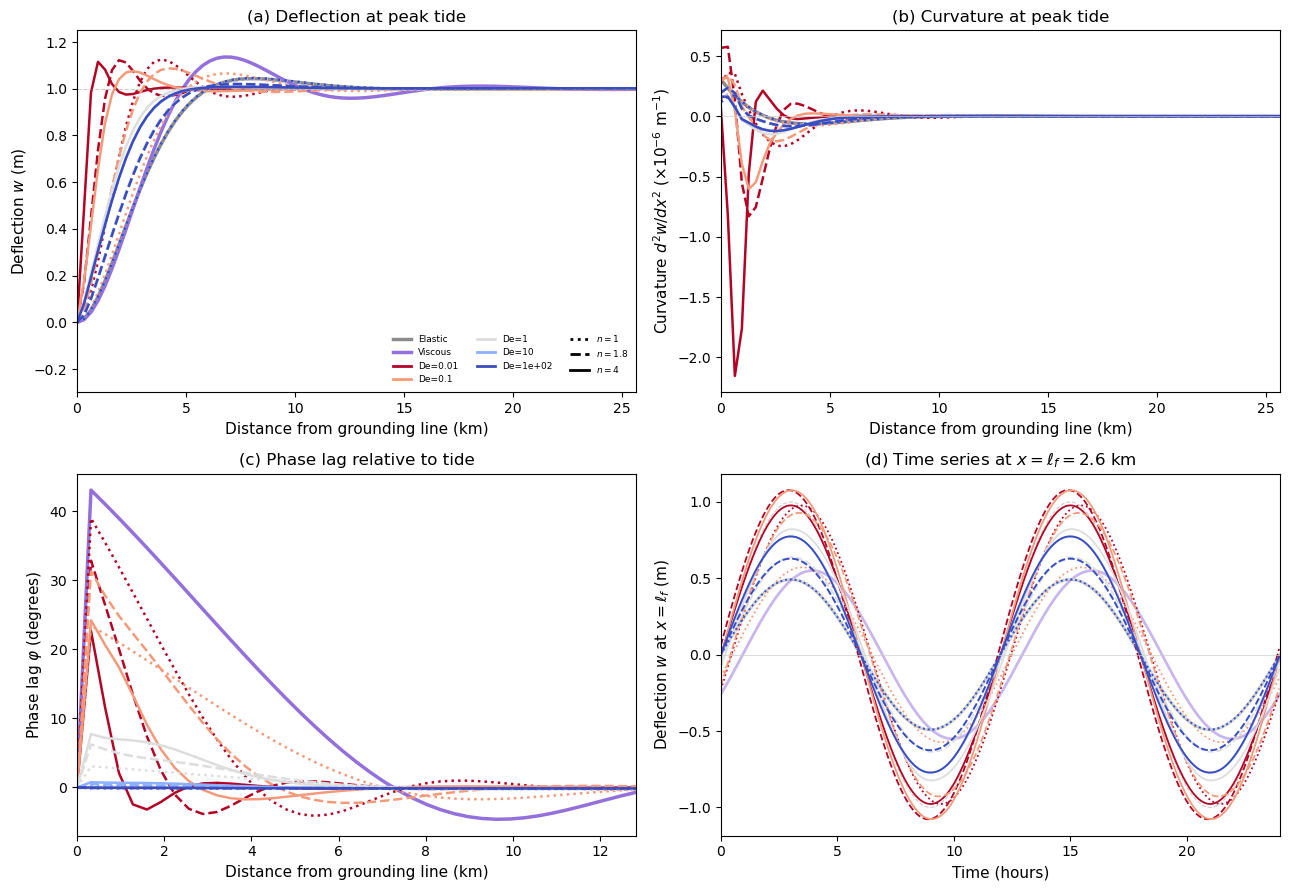

Saved fig14_powerlaw_viscoelastic_4panel.pdf/png


In [19]:
# ---- Fig 14: Plotting ----
from matplotlib.lines import Line2D

cmap_de_14 = plt.cm.coolwarm_r
De_log_14 = np.log10(De_targets_14)
norm_de_14 = plt.Normalize(De_log_14.min(), De_log_14.max())
lstyles_14 = {1: ':', 1.8: '--', 4: '-'}
nlabels_14 = {1: '$n=1$', 1.8: '$n=1.8$', 4: '$n=4$'}
color_el_14 = '0.55'; color_visc_14 = 'mediumpurple'

def de_color_14(De):
    return cmap_de_14(norm_de_14(np.log10(De)))

# Elastic reference
def elastic_w_14(x, t):
    xi = x / ell_f_ve
    return w0_ve*np.sin(omega_ve*t)*(1 - np.exp(-xi)*(np.cos(xi)+np.sin(xi)))
def elastic_kappa_14(x, t):
    xi = x / ell_f_ve
    return w0_ve*np.sin(omega_ve*t)*2*np.exp(-xi)*(np.cos(xi)-np.sin(xi))/ell_f_ve**2

# Pure viscous (n=1) reference at De=0.1
De_visc_ref = 0.1
D_v_visc_14 = De_visc_ref * mu * T_tide_ve * h_ve**3 / 3
W_vr14 = viscoelastic_complex_amplitude(
    x_ve, w0_ve, D_v_visc_14, 1e30, omega_ve, rho_w, g)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) Deflection at peak tide
ax = axes[0, 0]
ax.plot(x_ve/1e3, elastic_w_14(x_ve, T_tide_ve/4), '-', color=color_el_14,
        lw=2.5, zorder=0)
t_vp14 = (np.pi/2 + np.angle(W_vr14[-1])) / omega_ve
ax.plot(x_ve/1e3, np.imag(W_vr14*np.exp(1j*omega_ve*t_vp14)), '-',
        color=color_visc_14, lw=2.5, zorder=0)
for De in De_targets_14:
    for n_val in n_values_14:
        r = results_14[(n_val, De)]
        phase = omega_ve * r['t_hist']; idx = np.argmax(np.sin(phase))
        ax.plot(x_ve/1e3, r['w_hist'][idx], lstyles_14[n_val],
                color=de_color_14(De), lw=1.8)
ax.axhline(w0_ve, color='gray', ls='--', lw=0.8, alpha=0.4)
ax.set_xlabel('Distance from grounding line (km)', fontsize=11)
ax.set_ylabel('Deflection $w$ (m)', fontsize=11)
ax.set_title('(a) Deflection at peak tide', fontsize=12)
ax.set_xlim(0, L_ve/1e3); ax.set_ylim(-0.3, 1.25)
h_de = [Line2D([],[],color=de_color_14(d),lw=2,label=f'De={d:.2g}') for d in De_targets_14]
h_n = [Line2D([],[],color='k',ls=lstyles_14[n],lw=2,label=nlabels_14[n]) for n in n_values_14]
h_ref = [Line2D([],[],color=color_el_14,lw=2.5,label='Elastic'),
         Line2D([],[],color=color_visc_14,lw=2.5,label='Viscous')]
ax.legend(handles=h_ref+h_de+h_n, fontsize=6.5, frameon=False, ncol=3, loc='lower right')

# (b) Curvature at peak tide
ax = axes[0, 1]
ax.plot(x_ve/1e3, elastic_kappa_14(x_ve, T_tide_ve/4)*1e6, '-',
        color=color_el_14, lw=2.5)
for De in De_targets_14:
    for n_val in n_values_14:
        r = results_14[(n_val, De)]
        phase = omega_ve*r['t_hist']; idx = np.argmax(np.sin(phase))
        kappa = np.gradient(np.gradient(r['w_hist'][idx], x_ve), x_ve)
        ax.plot(x_ve/1e3, kappa*1e6, lstyles_14[n_val],
                color=de_color_14(De), lw=1.8)
ax.axhline(0, color='0.8', ls='-', lw=0.5)
ax.set_xlabel('Distance from grounding line (km)', fontsize=11)
ax.set_ylabel(r'Curvature $d^2w/dx^2$ ($\times 10^{-6}$ m$^{-1}$)', fontsize=11)
ax.set_title('(b) Curvature at peak tide', fontsize=12)
ax.set_xlim(0, L_ve/1e3)

# (c) Phase lag
ax = axes[1, 0]
ax.axhline(0, color=color_el_14, ls='-', lw=2.5, alpha=0.5)
phi_visc_ana = -np.degrees(np.angle(W_vr14))
ax.plot(x_ve/1e3, phi_visc_ana, '-', color=color_visc_14, lw=2.5)
for De in De_targets_14:
    for n_val in n_values_14:
        r = results_14[(n_val, De)]
        ax.plot(x_ve/1e3, r['phi_profile'], lstyles_14[n_val],
                color=de_color_14(De), lw=1.8)
ax.set_xlabel('Distance from grounding line (km)', fontsize=11)
ax.set_ylabel(r'Phase lag $\varphi$ (degrees)', fontsize=11)
ax.set_title('(c) Phase lag relative to tide', fontsize=12)
ax.set_xlim(0, 5*ell_f_ve/1e3)

# (d) Time series at x = ell_f
ax = axes[1, 1]
t_an = np.linspace(0, 2*T_tide_ve, 500)
ax.plot(t_an/3600, elastic_w_14(ell_f_ve, t_an), '-', color=color_el_14,
        lw=2, alpha=0.5)
w_visc_ts = viscoelastic_analytical(
    np.array([ell_f_ve]), t_an, w0_ve, D_v_visc_14, 1e30, omega_ve, rho_w, g)
ax.plot(t_an/3600, w_visc_ts[:,0], '-', color=color_visc_14, lw=2, alpha=0.5)
ax.plot(t_an/3600, w0_ve*np.sin(omega_ve*t_an), 'k--', lw=0.8, alpha=0.2)
for De in De_targets_14:
    for n_val in n_values_14:
        r = results_14[(n_val, De)]
        ax.plot(r['t_ts']/3600, r['w_ts'], lstyles_14[n_val],
                color=de_color_14(De), lw=1.3)
ax.axhline(0, color='0.8', ls='-', lw=0.5)
ax.set_xlabel('Time (hours)', fontsize=11)
ax.set_ylabel(r'Deflection $w$ at $x = \ell_f$ (m)', fontsize=11)
ax.set_title(f'(d) Time series at $x = \\ell_f = {ell_f_ve/1e3:.1f}$ km', fontsize=12)
ax.set_xlim(0, 2*T_tide_ve/3600)

fig.tight_layout()
fig.savefig('figures/fig14_powerlaw_viscoelastic_4panel.pdf', bbox_inches='tight')
fig.savefig('figures/fig14_powerlaw_viscoelastic_4panel.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig14_powerlaw_viscoelastic_4panel.pdf/png')